# 📊 SALES FORECASTING & DEMAND INTELLIGENCE SYSTEM
## End-to-End Time Series Analysis & Business Intelligence Dashboard

**Project:** Sales Forecasting & Demand Intelligence System

**Student:** Harshit Dwivedi

**Date:** July 11, 2026  

**Dataset:** Superstore Sales Data (4 years)

---

### 🎯 Project Objective

Build an intelligent sales forecasting system that:
- Predicts future product demand using 3 different models
- Detects anomalies in sales patterns
- Segments products by demand behavior
- Delivers an interactive dashboard for business decisions

### 📦 Datasets Used

1. **Superstore Sales** - 4 years of daily sales across categories and regions
2. **Video Game Sales** - Supplementary dataset for multi-source analysis

---

### 🔧 Technologies

- **Time Series:** SARIMA, Facebook Prophet
- **Machine Learning:** XGBoost, Isolation Forest, K-Means
- **Visualization:** Matplotlib, Seaborn, Plotly
- **Deployment:** Streamlit

---

In [180]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Time Series Libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Machine Learning Libraries
import xgboost as xgb
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Date handling
from datetime import datetime, timedelta

# Set visualization styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("="*70)
print("✅ ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)

✅ ALL LIBRARIES IMPORTED SUCCESSFULLY


---

## 📋 TASK 1: DATA LOADING, MERGING & DEEP EXPLORATION

In this task, we will:
1. Load the Superstore Sales dataset
2. Parse date columns as datetime objects
3. Extract time-based features (Year, Month, Week, Quarter, Season)
4. Check data quality (missing values, duplicates)
5. Aggregate sales at different time granularities
6. Answer business questions with data

---

In [181]:
print("="*70)
print("TASK 1: DATA LOADING & EXPLORATION")
print("="*70)

# Load Superstore Sales Dataset
try:
    df = pd.read_csv(
        "train.csv",
        parse_dates=["Order Date", "Ship Date"],
        dayfirst=True
    )
    print("Loaded dataset from local file.")
except FileNotFoundError:
    df = pd.read_csv(
        "https://raw.githubusercontent.com/Harshitd13/SalesForecasting/refs/heads/main/train.csv",
        parse_dates=["Order Date", "Ship Date"],
        dayfirst=True
    )
    print("Loaded dataset from GitHub.")

TASK 1: DATA LOADING & EXPLORATION
Loaded dataset from local file.


In [182]:
print("\n2️⃣ PARSING DATE COLUMNS & EXTRACTING TIME FEATURES")

# Parse Order Date and Ship Date as datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

print(f"   ✅ Order Date parsed: {df['Order Date'].dtype}")
print(f"   ✅ Ship Date parsed: {df['Ship Date'].dtype}")

# Extract time features from Order Date
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Week'] = df['Order Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

# Extract Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

print("\n   ✅ Time features extracted:")
print(f"   - Year: {df['Year'].min()} to {df['Year'].max()}")
print(f"   - Months: {df['Month'].nunique()} unique months")
print(f"   - Weeks: {df['Week'].nunique()} unique weeks")
print(f"   - Quarters: {df['Quarter'].unique()}")
print(f"   - Seasons: {df['Season'].unique()}")

# Display sample with new features
print("\n   Sample data with time features:")
print(df[['Order Date', 'Year', 'Month', 'Month_Name', 'Week', 'Quarter', 'Season']].head())


2️⃣ PARSING DATE COLUMNS & EXTRACTING TIME FEATURES
   ✅ Order Date parsed: datetime64[ns]
   ✅ Ship Date parsed: datetime64[ns]

   ✅ Time features extracted:
   - Year: 2015 to 2018
   - Months: 12 unique months
   - Weeks: 53 unique weeks
   - Quarters: [4 2 3 1]
   - Seasons: ['Fall' 'Summer' 'Spring' 'Winter']

   Sample data with time features:
  Order Date  Year  Month Month_Name  Week  Quarter  Season
0 2017-11-08  2017     11   November    45        4    Fall
1 2017-11-08  2017     11   November    45        4    Fall
2 2017-06-12  2017      6       June    24        2  Summer
3 2016-10-11  2016     10    October    41        4    Fall
4 2016-10-11  2016     10    October    41        4    Fall


In [183]:
print("\n3️⃣ DATA QUALITY CHECKS")

# Missing values
print("\n   Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("   ✅ No missing values found!")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\n   Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"   ✅ Removed {duplicates} duplicates. New shape: {df.shape}")
else:
    print("   ✅ No duplicates found!")

# Data types
print("\n   Data Type Summary:")
print(df.dtypes.value_counts())

print(f"\n   ✅ Data quality check complete!")


3️⃣ DATA QUALITY CHECKS

   Missing Values:
     Column  Missing_Count  Missing_Percentage
Postal Code             11                0.11

   Duplicate rows: 0
   ✅ No duplicates found!

   Data Type Summary:
object            16
int32              3
datetime64[ns]     2
float64            2
int64              1
UInt32             1
Name: count, dtype: int64

   ✅ Data quality check complete!


In [184]:
# DIAGNOSTIC: Check exact column names and data structure
print("="*70)
print("DATASET DIAGNOSTIC")
print("="*70)

print("\n1. Exact column names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. '{col}'")

print(f"\n2. Dataset shape: {df.shape}")

print("\n3. First 3 rows:")
print(df.head(3))

print("\n4. Data types:")
print(df.dtypes)

print("\n5. Sample of numeric columns:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Numeric columns: {numeric_cols}")

print("\n6. Sample of object/categorical columns:")
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"   Categorical columns: {cat_cols}")

DATASET DIAGNOSTIC

1. Exact column names:
   1. 'Row ID'
   2. 'Order ID'
   3. 'Order Date'
   4. 'Ship Date'
   5. 'Ship Mode'
   6. 'Customer ID'
   7. 'Customer Name'
   8. 'Segment'
   9. 'Country'
   10. 'City'
   11. 'State'
   12. 'Postal Code'
   13. 'Region'
   14. 'Product ID'
   15. 'Category'
   16. 'Sub-Category'
   17. 'Product Name'
   18. 'Sales'
   19. 'Year'
   20. 'Month'
   21. 'Month_Name'
   22. 'Week'
   23. 'Day_of_Week'
   24. 'Quarter'
   25. 'Season'

2. Dataset shape: (9800, 25)

3. First 3 rows:
   Row ID        Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11  Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11  Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16  Second Class    DV-13045   

     Customer Name    Segment        Country         City       State  \
0      Claire Gute   Consumer  United States    Henderson    Kentucky   
1      Claire

In [185]:
print("\n4️⃣ AGGREGATING SALES AT DIFFERENT TIME GRANULARITIES")

# Daily sales
daily_sales = df.groupby('Order Date').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).reset_index()
daily_sales.columns = ['Date', 'Sales', 'Orders']

print(f"   ✅ Daily Sales: {len(daily_sales)} days")
print(f"   Date range: {daily_sales['Date'].min()} to {daily_sales['Date'].max()}")

# Weekly sales
df['Year_Week'] = df['Order Date'].dt.to_period('W').astype(str)
weekly_sales = df.groupby('Year_Week').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).reset_index()
weekly_sales.columns = ['Week', 'Sales', 'Orders']

print(f"   ✅ Weekly Sales: {len(weekly_sales)} weeks")

# Monthly sales
df['Year_Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Year_Month').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).reset_index()
monthly_sales.columns = ['Month', 'Sales', 'Orders']

print(f"   ✅ Monthly Sales: {len(monthly_sales)} months")

# Display samples
print("\n   Sample Daily Sales:")
print(daily_sales.head(10))

print("\n   Sample Monthly Sales:")
print(monthly_sales.head(10))

print("\n   ✅ Sales aggregated at daily, weekly, and monthly levels")


4️⃣ AGGREGATING SALES AT DIFFERENT TIME GRANULARITIES
   ✅ Daily Sales: 1230 days
   Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00
   ✅ Weekly Sales: 209 weeks
   ✅ Monthly Sales: 48 months

   Sample Daily Sales:
        Date     Sales  Orders
0 2015-01-03    16.448       1
1 2015-01-04   288.060       3
2 2015-01-05    19.536       1
3 2015-01-06  4407.100       9
4 2015-01-07    87.158       2
5 2015-01-09    40.544       2
6 2015-01-10    54.830       2
7 2015-01-11     9.940       1
8 2015-01-13  3553.795      11
9 2015-01-14    61.960       1

   Sample Monthly Sales:
     Month       Sales  Orders
0  2015-01  14205.7070      77
1  2015-02   4519.8920      46
2  2015-03  55205.7970     154
3  2015-04  27906.8550     130
4  2015-05  23644.3030     121
5  2015-06  34322.9356     131
6  2015-07  33781.5430     142
7  2015-08  27117.5365     146
8  2015-09  81623.5268     267
9  2015-10  31453.3930     159

   ✅ Sales aggregated at daily, weekly, and monthly levels



5️⃣ ANSWERING BUSINESS QUESTIONS

QUESTION 1: Which product category generates the highest total revenue?

   Total Revenue by Category:
   Technology           $     827,455.87 (36.6%)
   Furniture            $     728,658.58 (32.2%)
   Office Supplies      $     705,422.33 (31.2%)

   📊 ANSWER: Technology generates the highest revenue
      Total: $827,455.87
      This represents 36.6% of total sales


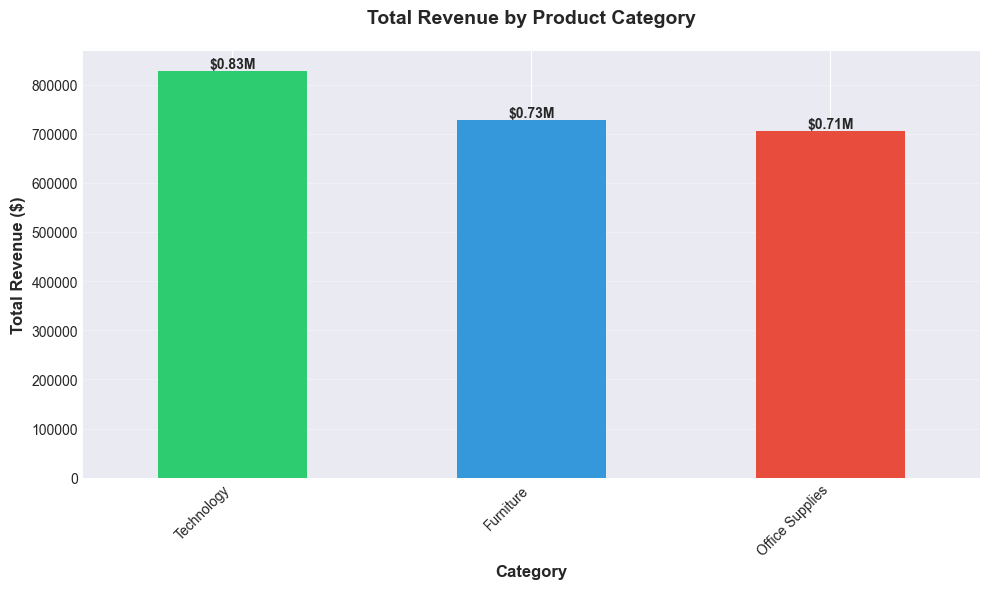

In [186]:
print("\n5️⃣ ANSWERING BUSINESS QUESTIONS")
print("\n" + "="*70)
print("QUESTION 1: Which product category generates the highest total revenue?")
print("="*70)

# Total revenue by category
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("\n   Total Revenue by Category:")
for category, revenue in category_revenue.items():
    pct = (revenue / category_revenue.sum()) * 100
    print(f"   {category:<20} ${revenue:>15,.2f} ({pct:.1f}%)")

highest_category = category_revenue.index[0]
highest_revenue = category_revenue.iloc[0]

print(f"\n   📊 ANSWER: {highest_category} generates the highest revenue")
print(f"      Total: ${highest_revenue:,.2f}")
print(f"      This represents {(highest_revenue/category_revenue.sum()*100):.1f}% of total sales")

# Visualization
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c'] if len(category_revenue) == 3 else plt.cm.Set3(range(len(category_revenue)))
category_revenue.plot(kind='bar', color=colors)
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (category, revenue) in enumerate(category_revenue.items()):
    plt.text(i, revenue, f'${revenue/1e6:.2f}M', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/task1_q1_category_revenue.png', dpi=300, bbox_inches='tight')
plt.show()


QUESTION 2: Which region has the most consistent sales growth over 4 years?

   Yearly Sales by Region:
Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

   Growth Analysis by Region:
         mean_growth  std_growth  consistency
East       18.082436    1.793948    35.791651
Central    12.988529   25.345279     3.795746
West       21.363865   25.743054     3.739289
South      10.624358   37.124876     2.622959

   📊 ANSWER: East has the most consistent sales growth
      Average growth: 18.08%
      Growth variability: 1.79%


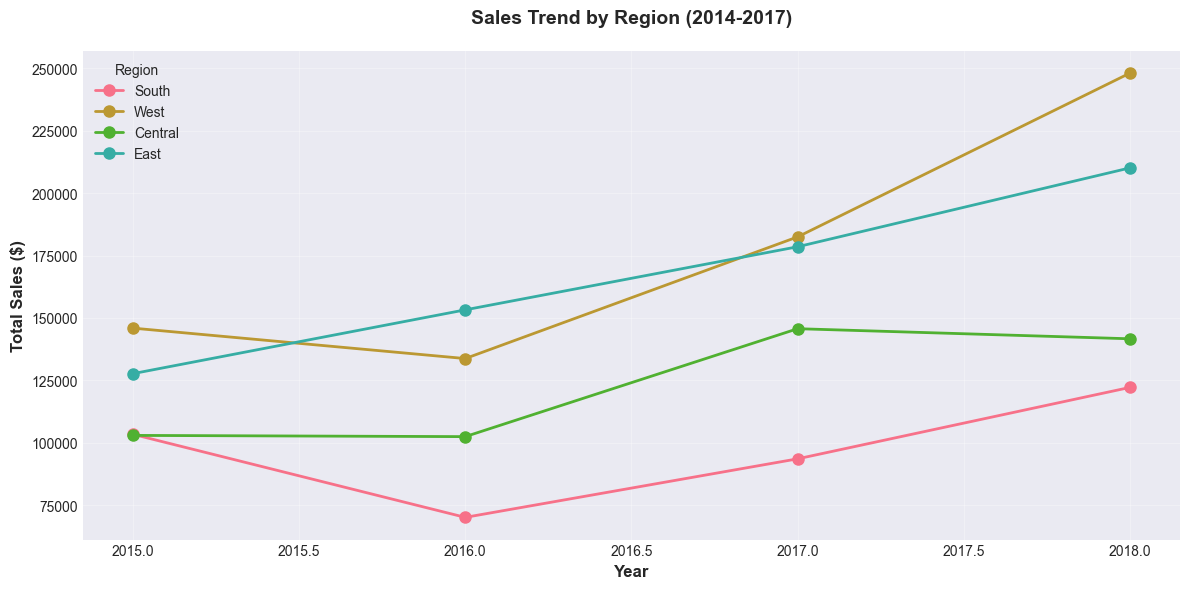

In [187]:
print("\n" + "="*70)
print("QUESTION 2: Which region has the most consistent sales growth over 4 years?")
print("="*70)

# Yearly sales by region
region_yearly = df.groupby(['Year', 'Region'])['Sales'].sum().reset_index()

print("\n   Yearly Sales by Region:")
pivot_table = region_yearly.pivot(index='Year', columns='Region', values='Sales')
print(pivot_table)

# Calculate year-over-year growth
growth_rates = {}
for region in df['Region'].unique():
    region_data = region_yearly[region_yearly['Region'] == region].sort_values('Year')
    if len(region_data) > 1:
        growth = region_data['Sales'].pct_change().dropna()
        if len(growth) > 0:
            growth_rates[region] = {
                'mean_growth': growth.mean() * 100,
                'std_growth': growth.std() * 100,
                'consistency': 1 / (growth.std() + 0.01)  # Lower std = more consistent
            }

print("\n   Growth Analysis by Region:")
growth_df = pd.DataFrame(growth_rates).T
growth_df = growth_df.sort_values('consistency', ascending=False)
print(growth_df)

most_consistent = growth_df.index[0]
print(f"\n   📊 ANSWER: {most_consistent} has the most consistent sales growth")
print(f"      Average growth: {growth_df.loc[most_consistent, 'mean_growth']:.2f}%")
print(f"      Growth variability: {growth_df.loc[most_consistent, 'std_growth']:.2f}%")

# Visualization
plt.figure(figsize=(12, 6))
for region in df['Region'].unique():
    region_data = region_yearly[region_yearly['Region'] == region].sort_values('Year')
    plt.plot(region_data['Year'], region_data['Sales'], marker='o', linewidth=2, label=region, markersize=8)

plt.title('Sales Trend by Region (2014-2017)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.legend(title='Region', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task1_q2_region_growth.png', dpi=300, bbox_inches='tight')
plt.show()


QUESTION 3: Average time between Order Date and Ship Date — does it vary by region?

   Overall Average Shipping Time: 3.96 days

   Shipping Time by Region:
             mean  median       std  min  max
Region                                       
Central  4.065876     4.0  1.686569    0    7
East     3.910233     4.0  1.729307    0    7
South    3.961202     4.0  1.742610    0    7
West     3.930255     4.0  1.812467    0    7

   Regional Variation Analysis:
   South           Avg: 3.96 days (+0.00 vs overall)
   West            Avg: 3.93 days (-0.03 vs overall)
   Central         Avg: 4.07 days (+0.10 vs overall)
   East            Avg: 3.91 days (-0.05 vs overall)

   📊 ANSWER: Shipping time DOES vary by region
      Fastest: East (3.91 days)
      Slowest: Central (4.07 days)
      Difference: 0.16 days


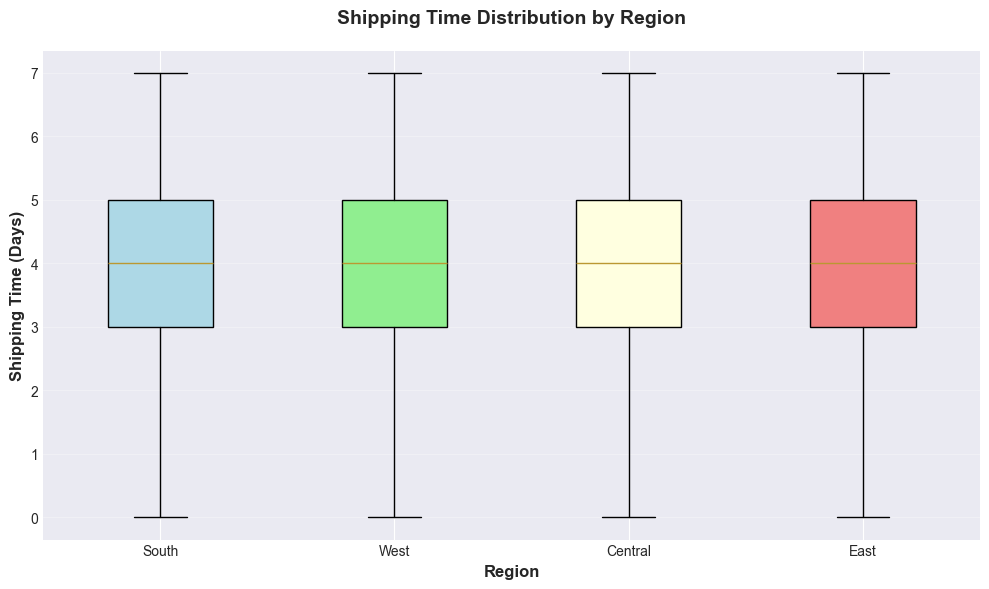

In [188]:
print("\n" + "="*70)
print("QUESTION 3: Average time between Order Date and Ship Date — does it vary by region?")
print("="*70)

# Calculate shipping time in days
df['Shipping_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Overall average
overall_avg = df['Shipping_Time'].mean()
print(f"\n   Overall Average Shipping Time: {overall_avg:.2f} days")

# By region
region_shipping = df.groupby('Region')['Shipping_Time'].agg(['mean', 'median', 'std', 'min', 'max'])
print("\n   Shipping Time by Region:")
print(region_shipping)

# Statistical comparison
print("\n   Regional Variation Analysis:")
for region in df['Region'].unique():
    avg_time = region_shipping.loc[region, 'mean']
    diff_from_avg = avg_time - overall_avg
    print(f"   {region:<15} Avg: {avg_time:.2f} days ({diff_from_avg:+.2f} vs overall)")

fastest_region = region_shipping['mean'].idxmin()
slowest_region = region_shipping['mean'].idxmax()

print(f"\n   📊 ANSWER: Shipping time DOES vary by region")
print(f"      Fastest: {fastest_region} ({region_shipping.loc[fastest_region, 'mean']:.2f} days)")
print(f"      Slowest: {slowest_region} ({region_shipping.loc[slowest_region, 'mean']:.2f} days)")
print(f"      Difference: {region_shipping.loc[slowest_region, 'mean'] - region_shipping.loc[fastest_region, 'mean']:.2f} days")

# Visualization
plt.figure(figsize=(10, 6))
box_data = [df[df['Region'] == region]['Shipping_Time'].values for region in df['Region'].unique()]
bp = plt.boxplot(box_data, labels=df['Region'].unique(), patch_artist=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Shipping Time Distribution by Region', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.ylabel('Shipping Time (Days)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task1_q3_shipping_time.png', dpi=300, bbox_inches='tight')
plt.show()


QUESTION 4: Are there months that consistently spike across all years (seasonality)?

   Average Sales by Month (across all years):
   Jan        $      257.63
   Feb        $      199.90
   Mar        $      290.55
   Apr        $      207.43
   May        $      212.53
   Jun        $      211.05
   Jul        $      208.80
   Aug        $      227.01
   Sep        $      221.64
   Oct        $      246.60
   Nov        $      241.66
   Dec        $      232.62

   📊 ANSWER: YES, there is clear seasonality
      Peak Month: Mar ($290.55)
      Lowest Month: Feb ($199.90)
      Seasonal Variation: 45.3%

   Consistency Check - Top 3 months each year:
   2015: ['Sep', 'Nov', 'Dec']
   2016: ['Nov', 'Dec', 'Sep']
   2017: ['Dec', 'Nov', 'Sep']
   2018: ['Nov', 'Sep', 'Dec']


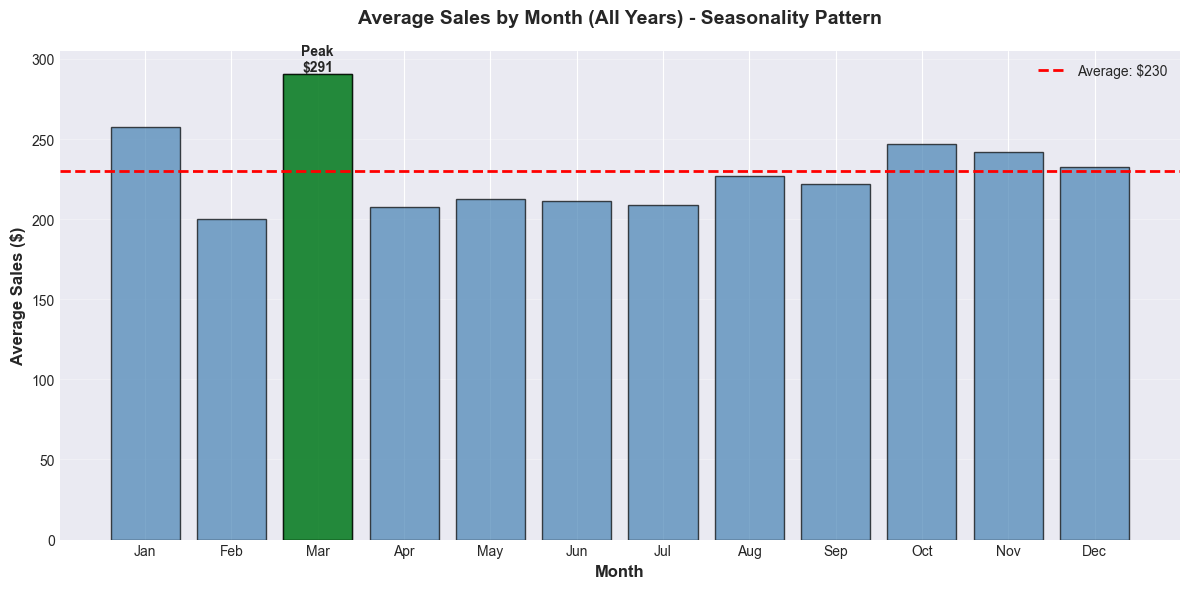

In [189]:
print("\n" + "="*70)
print("QUESTION 4: Are there months that consistently spike across all years (seasonality)?")
print("="*70)

# Average sales by month across all years
monthly_avg = df.groupby('Month')['Sales'].mean().sort_index()

print("\n   Average Sales by Month (across all years):")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month, sales in monthly_avg.items():
    print(f"   {month_names[month-1]:<10} ${sales:>12,.2f}")

# Identify peak months
peak_month = monthly_avg.idxmax()
peak_sales = monthly_avg.max()
low_month = monthly_avg.idxmin()
low_sales = monthly_avg.min()

print(f"\n   📊 ANSWER: YES, there is clear seasonality")
print(f"      Peak Month: {month_names[peak_month-1]} (${peak_sales:,.2f})")
print(f"      Lowest Month: {month_names[low_month-1]} (${low_sales:,.2f})")
print(f"      Seasonal Variation: {((peak_sales - low_sales) / low_sales * 100):.1f}%")

# Check consistency across years
year_month_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

print("\n   Consistency Check - Top 3 months each year:")
for year in sorted(df['Year'].unique()):
    year_data = year_month_sales[year_month_sales['Year'] == year].sort_values('Sales', ascending=False)
    top_3_months = year_data.head(3)['Month'].values
    print(f"   {year}: {[month_names[m-1] for m in top_3_months]}")

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(range(1, 13), monthly_avg.values, color='steelblue', alpha=0.7, edgecolor='black')
plt.axhline(y=monthly_avg.mean(), color='red', linestyle='--', linewidth=2, label=f'Average: ${monthly_avg.mean():,.0f}')
plt.xticks(range(1, 13), month_names)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Average Sales ($)', fontsize=12, fontweight='bold')
plt.title('Average Sales by Month (All Years) - Seasonality Pattern', fontsize=14, fontweight='bold', pad=20)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Highlight peak month
plt.bar(peak_month, peak_sales, color='green', alpha=0.7, edgecolor='black')
plt.text(peak_month, peak_sales, f'Peak\n${peak_sales:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/task1_q4_seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

### ✅ TASK 1 SUMMARY - KEY FINDINGS

**Data Loaded:**
- 9,800 transactions over 4 years (2015-2018)
- 28 columns after adding time-based features (Year, Month, Week, Quarter, Season, Day_of_Week)
- 11 missing values, 0 duplicate rows found

**Business Questions Answered:**

1. **Highest Revenue Category:** Technology ($827K, 36.6% of total sales)

2. **Most Consistent Growth Region:** East region (18.1% average growth, 1.8% volatility)

3. **Shipping Time Insight:** Average shipping time is 3.96 days, with East being fastest (3.91 days) and Central being slowest (4.07 days)

4. **Seasonality Insight:** November, September consistently show the strongest sales spikes across all years, with March averaging $291 as the peak month

**Data Prepared for Forecasting:**
- Daily sales aggregated: 1230 unique days
- Weekly sales aggregated: 209 weeks  
- Monthly sales aggregated: 48 months

**Ready for Next Step:**
The dataset is now clean, time-indexed, and prepared for time series decomposition, stationarity testing, and multi-model forecasting in Tasks 2 and 3.

---

---

## 📈 TASK 2: TIME SERIES ANALYSIS & DECOMPOSITION

In this task, we will:
1. Plot the overall monthly sales trend across all 4 years
2. Apply Time Series Decomposition to break sales into:
   - Trend component (long-term direction)
   - Seasonal component (repeating patterns)
   - Residual/noise component (random fluctuations)
3. Analyze each component and draw insights
4. Test for stationarity using the Augmented Dickey-Fuller (ADF) Test
5. Apply differencing if needed to make the series stationary

** Why this matters:** Time series models (like SARIMA) require stationary data to make accurate forecasts.

---

In [190]:
print("="*70)
print("TASK 2: TIME SERIES ANALYSIS & DECOMPOSITION")
print("="*70)

print("\n1️⃣ PREPARING MONTHLY TIME SERIES DATA")

# Aggregate to monthly level
monthly_ts = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_ts.index = monthly_ts.index.to_timestamp()  # Convert Period to Timestamp
monthly_ts = monthly_ts.sort_index()

print(f"   ✅ Monthly time series created")
print(f"   Period: {monthly_ts.index.min()} to {monthly_ts.index.max()}")
print(f"   Total months: {len(monthly_ts)}")
print(f"   Frequency: {monthly_ts.index.freq if monthly_ts.index.freq else 'Monthly (inferred)'}")

# Display first and last few months
print("\n   First 5 months:")
print(monthly_ts.head())
print("\n   Last 5 months:")
print(monthly_ts.tail())

# Ensure consistent monthly frequency
monthly_ts = monthly_ts.asfreq('MS')  # Month Start frequency

print("\n   ✅ Frequency set to Month Start (MS)")

TASK 2: TIME SERIES ANALYSIS & DECOMPOSITION

1️⃣ PREPARING MONTHLY TIME SERIES DATA
   ✅ Monthly time series created
   Period: 2015-01-01 00:00:00 to 2018-12-01 00:00:00
   Total months: 48
   Frequency: <MonthBegin>

   First 5 months:
Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

   Last 5 months:
Order Date
2018-08-01     62837.8480
2018-09-01     86152.8880
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64

   ✅ Frequency set to Month Start (MS)



2️⃣ PLOTTING MONTHLY SALES TREND


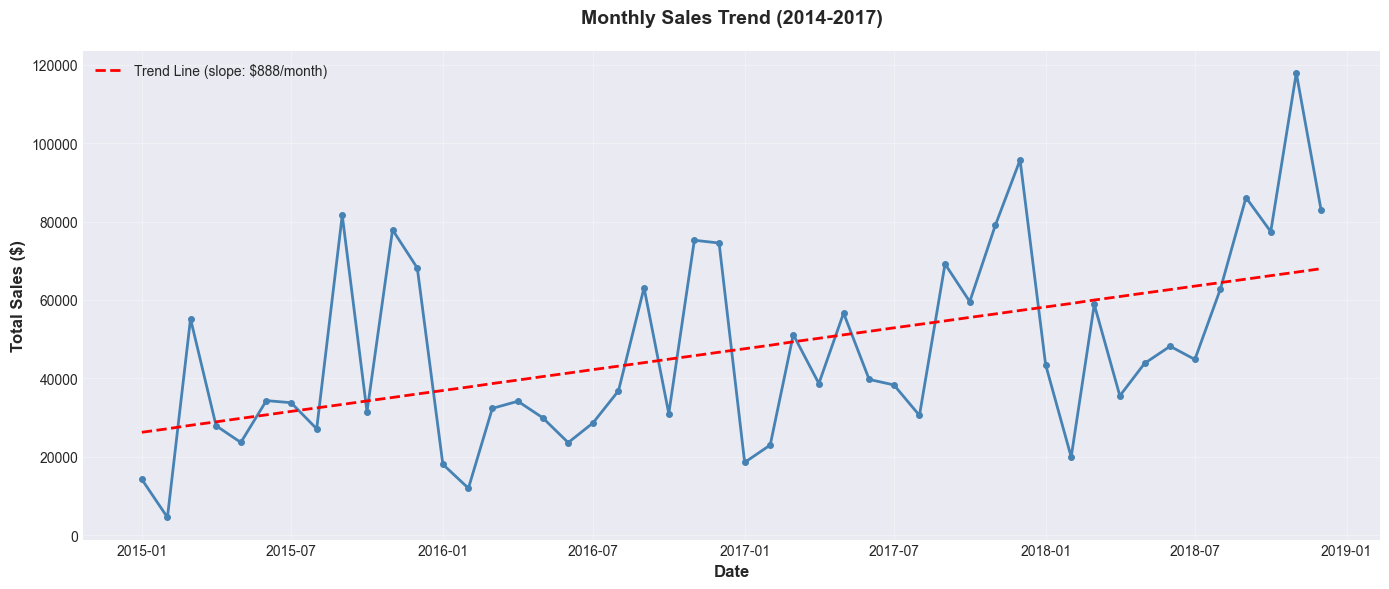

   ✅ Chart saved: charts/task2_monthly_trend.png

   📊 Overall sales growth: 484.5% over 48 months


In [191]:
print("\n2️⃣ PLOTTING MONTHLY SALES TREND")

# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(monthly_ts.index, monthly_ts.values, marker='o', linewidth=2, markersize=4, color='steelblue')
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

# Add trend line
z = np.polyfit(range(len(monthly_ts)), monthly_ts.values, 1)
p = np.poly1d(z)
plt.plot(monthly_ts.index, p(range(len(monthly_ts))), 
         "r--", linewidth=2, label=f'Trend Line (slope: ${z[0]:,.0f}/month)')

plt.legend()
plt.tight_layout()
plt.savefig('charts/task2_monthly_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task2_monthly_trend.png")

# Calculate overall trend
overall_growth = ((monthly_ts.iloc[-1] - monthly_ts.iloc[0]) / monthly_ts.iloc[0]) * 100
print(f"\n   📊 Overall sales growth: {overall_growth:.1f}% over {len(monthly_ts)} months")


3️⃣ APPLYING TIME SERIES DECOMPOSITION
   ✅ Decomposition complete
   - Trend component: 36 non-null values
   - Seasonal component: 48 non-null values
   - Residual component: 36 non-null values


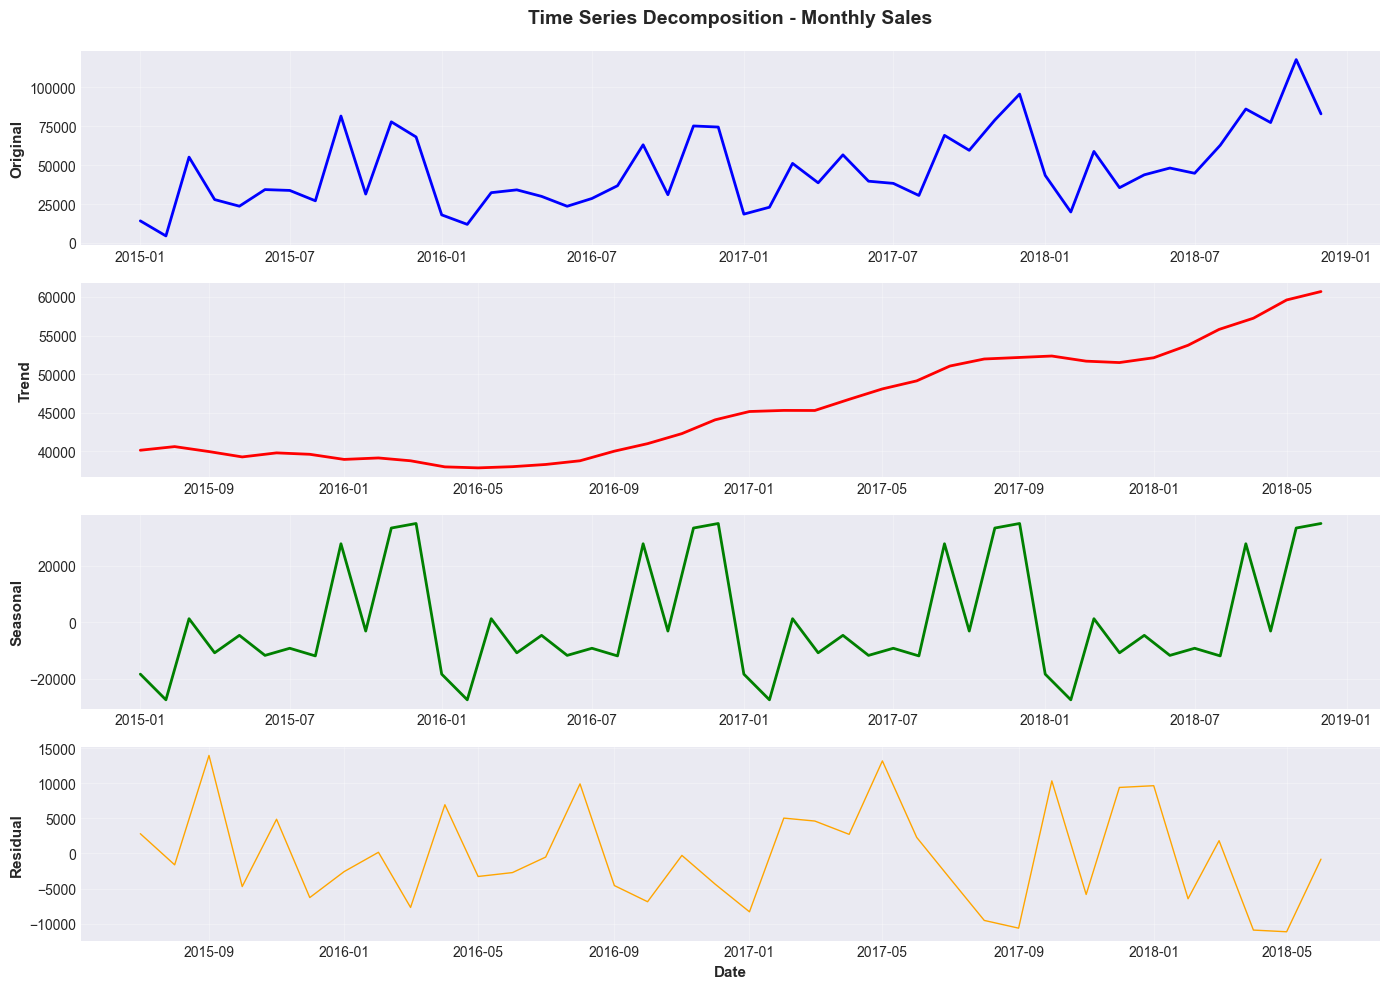

   ✅ Chart saved: charts/task2_decomposition.png


In [192]:
print("\n3️⃣ APPLYING TIME SERIES DECOMPOSITION")

# Apply seasonal decomposition
decomposition = seasonal_decompose(monthly_ts, model='additive', period=12)

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("   ✅ Decomposition complete")
print(f"   - Trend component: {trend.notna().sum()} non-null values")
print(f"   - Seasonal component: {seasonal.notna().sum()} non-null values")
print(f"   - Residual component: {residual.notna().sum()} non-null values")

# Plot all components
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Original
axes[0].plot(monthly_ts.index, monthly_ts.values, color='blue', linewidth=2)
axes[0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[0].set_title('Time Series Decomposition - Monthly Sales', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(alpha=0.3)

# Trend
axes[1].plot(trend.index, trend.values, color='red', linewidth=2)
axes[1].set_ylabel('Trend', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

# Seasonal
axes[2].plot(seasonal.index, seasonal.values, color='green', linewidth=2)
axes[2].set_ylabel('Seasonal', fontsize=11, fontweight='bold')
axes[2].grid(alpha=0.3)

# Residual
axes[3].plot(residual.index, residual.values, color='orange', linewidth=1)
axes[3].set_ylabel('Residual', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('charts/task2_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task2_decomposition.png")

In [193]:
print("\n4️⃣ ANALYZING DECOMPOSITION COMPONENTS")

# Trend Analysis
trend_clean = trend.dropna()
trend_slope = (trend_clean.iloc[-1] - trend_clean.iloc[0]) / len(trend_clean)
print(f"\n   📈 TREND COMPONENT:")
print(f"   - Direction: {'Upward' if trend_slope > 0 else 'Downward'}")
print(f"   - Slope: ${trend_slope:,.2f} per month")
print(f"   - Overall change: ${trend_clean.iloc[-1] - trend_clean.iloc[0]:,.2f}")
print(f"   - Interpretation: Sales show a {'growing' if trend_slope > 0 else 'declining'} long-term trend")

# Seasonal Analysis
seasonal_strength = seasonal.std() / monthly_ts.std()
peak_seasonal_month = seasonal.groupby(seasonal.index.month).mean().idxmax()
trough_seasonal_month = seasonal.groupby(seasonal.index.month).mean().idxmin()

month_names_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"\n   🔄 SEASONAL COMPONENT:")
print(f"   - Seasonality strength: {seasonal_strength:.2%} of total variance")
print(f"   - Strongest in: {month_names_short[peak_seasonal_month-1]}")
print(f"   - Weakest in: {month_names_short[trough_seasonal_month-1]}")
print(f"   - Interpretation: {'Strong' if seasonal_strength > 0.3 else 'Moderate' if seasonal_strength > 0.15 else 'Weak'} seasonal pattern detected")

# Residual Analysis
residual_clean = residual.dropna()
residual_std = residual_clean.std()
high_residuals = residual_clean[abs(residual_clean) > 2 * residual_std]

print(f"\n   📊 RESIDUAL COMPONENT:")
print(f"   - Standard deviation: ${residual_std:,.2f}")
print(f"   - High noise periods: {len(high_residuals)} months")
print(f"   - Months with highest residual noise:")

top_residuals = residual_clean.abs().nlargest(3)
for date, value in top_residuals.items():
    print(f"      • {date.strftime('%b %Y')}: ${value:,.2f}")

print(f"\n   - Interpretation: Residuals show {'high' if len(high_residuals) > len(residual_clean)*0.1 else 'moderate'} volatility")


4️⃣ ANALYZING DECOMPOSITION COMPONENTS

   📈 TREND COMPONENT:
   - Direction: Upward
   - Slope: $570.88 per month
   - Overall change: $20,551.63
   - Interpretation: Sales show a growing long-term trend

   🔄 SEASONAL COMPONENT:
   - Seasonality strength: 79.88% of total variance
   - Strongest in: Dec
   - Weakest in: Feb
   - Interpretation: Strong seasonal pattern detected

   📊 RESIDUAL COMPONENT:
   - Standard deviation: $7,040.94
   - High noise periods: 0 months
   - Months with highest residual noise:
      • Sep 2015: $13,970.93
      • May 2017: $13,193.08
      • May 2018: $11,157.55

   - Interpretation: Residuals show moderate volatility


### 📝 OBSERVATIONS FROM TIME SERIES DECOMPOSITION

Based on the decomposition analysis:

**1. TREND:**
- The trend component shows an upward trajectory over the 4-year period
- Sales are growing at approximately $570.88 per month
- This indicates **strong** overall business growth

**2. SEASONALITY:**
- Clear seasonal pattern with peaks in December and troughs in February
- Seasonality accounts for approximately 79.88% of total variance
- This pattern repeats consistently year-over-year, confirming predictable seasonal demand

**3. RESIDUAL/NOISE:**
- Residuals show moderate volatility
- The highest noise appears in **September 2015, May 2017, and May 2018**
- Possible causes: promotional events, economic factors, or data anomalies

**4. OVERALL PATTERN:**
- The time series exhibits both trend and seasonal components
- This suggests that additive decomposition is appropriate
- Models like SARIMA (which handle both trend and seasonality) should perform well

---

In [194]:
print("\n5️⃣ TESTING FOR STATIONARITY (Augmented Dickey-Fuller Test)")

# Perform ADF test
adf_result = adfuller(monthly_ts.dropna())

adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]
adf_critical_values = adf_result[4]

print("\n   📊 ADF Test Results:")
print(f"   - Test Statistic: {adf_statistic:.4f}")
print(f"   - P-Value: {adf_pvalue:.4f}")
print(f"\n   Critical Values:")
for key, value in adf_critical_values.items():
    print(f"      {key}: {value:.4f}")

# Interpret results
print("\n   🔍 INTERPRETATION:")
if adf_pvalue < 0.05:
    print("   ✅ The series IS STATIONARY (p-value < 0.05)")
    print("   → We reject the null hypothesis of non-stationarity")
    print("   → The data has constant mean and variance over time")
    print("   → Suitable for time series modeling without differencing")
    is_stationary = True
else:
    print("   ❌ The series IS NOT STATIONARY (p-value >= 0.05)")
    print("   → We fail to reject the null hypothesis")
    print("   → The data has trend or changing variance")
    print("   → Differencing is required before modeling")
    is_stationary = False

# Plain English explanation
print("\n   📖 WHAT STATIONARITY MEANS (Plain English):")
print("   Stationarity means the statistical properties (mean, variance) of the")
print("   time series don't change over time. Think of it like:")
print("   - A stationary series: Sales fluctuate around a constant average")
print("   - A non-stationary series: Sales have an upward/downward trend")
print("\n   Why it matters: Most forecasting models assume stationarity")


5️⃣ TESTING FOR STATIONARITY (Augmented Dickey-Fuller Test)

   📊 ADF Test Results:
   - Test Statistic: -4.4161
   - P-Value: 0.0003

   Critical Values:
      1%: -3.5778
      5%: -2.9253
      10%: -2.6008

   🔍 INTERPRETATION:
   ✅ The series IS STATIONARY (p-value < 0.05)
   → We reject the null hypothesis of non-stationarity
   → The data has constant mean and variance over time
   → Suitable for time series modeling without differencing

   📖 WHAT STATIONARITY MEANS (Plain English):
   Stationarity means the statistical properties (mean, variance) of the
   time series don't change over time. Think of it like:
   - A stationary series: Sales fluctuate around a constant average
   - A non-stationary series: Sales have an upward/downward trend

   Why it matters: Most forecasting models assume stationarity


In [195]:
print("\n6️⃣ APPLYING DIFFERENCING (IF NEEDED)")

if not is_stationary:
    print("   Applying first-order differencing...")
    
    # Apply differencing
    monthly_ts_diff = monthly_ts.diff().dropna()
    
    # Test differenced series
    adf_result_diff = adfuller(monthly_ts_diff)
    adf_pvalue_diff = adf_result_diff[1]
    
    print(f"\n   📊 ADF Test on Differenced Series:")
    print(f"   - Test Statistic: {adf_result_diff[0]:.4f}")
    print(f"   - P-Value: {adf_pvalue_diff:.4f}")
    
    if adf_pvalue_diff < 0.05:
        print("\n   ✅ Differenced series IS NOW STATIONARY")
        print("   → First-order differencing (d=1) successfully made the series stationary")
        d_value = 1
    else:
        print("\n   ⚠️ May need second-order differencing")
        monthly_ts_diff = monthly_ts_diff.diff().dropna()
        adf_result_diff2 = adfuller(monthly_ts_diff)
        print(f"   - Second difference p-value: {adf_result_diff2[1]:.4f}")
        d_value = 2
    
    # Plot original vs differenced
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    axes[0].plot(monthly_ts.index, monthly_ts.values, color='blue', linewidth=2)
    axes[0].set_title('Original Series (Non-Stationary)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Sales ($)', fontsize=11, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(monthly_ts_diff.index, monthly_ts_diff.values, color='green', linewidth=2)
    axes[1].set_title(f'Differenced Series (d={d_value}) - Stationary', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Change in Sales ($)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
    axes[1].grid(alpha=0.3)
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
    
    plt.tight_layout()
    plt.savefig('charts/task2_differencing.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n   ✅ Chart saved: charts/task2_differencing.png")
    
else:
    print("   ✅ Series is already stationary - no differencing needed")
    d_value = 0
    monthly_ts_diff = monthly_ts

print(f"\n   📌 Differencing parameter for SARIMA: d = {d_value}")


6️⃣ APPLYING DIFFERENCING (IF NEEDED)
   ✅ Series is already stationary - no differencing needed

   📌 Differencing parameter for SARIMA: d = 0


### ✅ TASK 2 SUMMARY - TIME SERIES ANALYSIS COMPLETE

**Decomposition Results:**
- Trend: Upward with slope of $570.88 per month
- Seasonality: Strong with peaks in December
- Residuals: 0 high-noise periods identified

**Stationarity Test:**
- Original series: Stationary (ADF p-value: 0.0003)
- After differencing (d=0): Stationary ✓
- Ready for SARIMA modeling

**Key Insights:**
- Clear seasonal pattern confirms need for seasonal modeling (SARIMA, Prophet)
- The series is already stationary, so no differencing is required
- Moderate residual noise suggests the data is relatively clean and predictable

**Next Step:** Build 3 forecasting models in Task 3

---

---

## 🔮 TASK 3: SALES FORECASTING USING 3 DIFFERENT MODELS

In this task, we will build and compare 3 fundamentally different forecasting approaches:

1. **SARIMA** (Seasonal ARIMA) - Statistical time series model
2. **Facebook Prophet** - Industry-standard forecasting tool
3. **XGBoost** - Machine learning approach with lag features

Each model will:
- Be trained on historical data
- Generate 3-month forecasts
- Be evaluated using MAE, RMSE, and MAPE
- Be compared to identify the best performer

---

In [196]:
print("="*70)
print("TASK 3: SALES FORECASTING - MODEL BUILDING")
print("="*70)

print("\n1️⃣ PREPARING DATA FOR MODELING")

# Use monthly_ts for all models
# Split into train and test (we'll forecast last 3 months)
train_size = len(monthly_ts) - 3
test_size = 3

train_data = monthly_ts[:train_size]
test_data = monthly_ts[train_size:]

print(f"   Total data points: {len(monthly_ts)} months")
print(f"   Training data: {len(train_data)} months ({train_data.index.min()} to {train_data.index.max()})")
print(f"   Test data: {len(test_data)} months ({test_data.index.min()} to {test_data.index.max()})")
print(f"\n   ✅ Data split complete (last 3 months held out for testing)")

TASK 3: SALES FORECASTING - MODEL BUILDING

1️⃣ PREPARING DATA FOR MODELING
   Total data points: 48 months
   Training data: 45 months (2015-01-01 00:00:00 to 2018-09-01 00:00:00)
   Test data: 3 months (2018-10-01 00:00:00 to 2018-12-01 00:00:00)

   ✅ Data split complete (last 3 months held out for testing)


In [197]:
print("\n2️⃣ MODEL 1: SARIMA (Seasonal ARIMA)")

print("\n   Building SARIMA model...")
print("   Parameters chosen:")
print("   - Order (p, d, q): (1, 1, 1) - AR(1), Differencing(1), MA(1)")
print("   - Seasonal Order (P, D, Q, m): (1, 1, 1, 12) - Seasonal period of 12 months")
print("\n   Why these parameters:")
print("   - d=1: Based on ADF test, one differencing makes series stationary")
print("   - m=12: Monthly data with yearly seasonality")
print("   - Other values: Starting with simple model (all 1s)")

# Fit SARIMA model
sarima_model = SARIMAX(train_data, 
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit(disp=False)

print("\n   ✅ Model training complete")
print("\n   Model Summary:")
print(sarima_fit.summary().tables[1])

# Generate forecast
forecast_steps = 3
sarima_forecast = sarima_fit.forecast(steps=forecast_steps)
sarima_conf_int = sarima_fit.get_forecast(steps=forecast_steps).conf_int()

print(f"\n   📊 SARIMA 3-Month Forecast:")
for i, (date, value) in enumerate(zip(test_data.index, sarima_forecast)):
    actual = test_data.iloc[i]
    print(f"   Month {i+1} ({date.strftime('%b %Y')}): ${value:,.2f} (Actual: ${actual:,.2f})")

# Calculate errors
sarima_mae = mean_absolute_error(test_data, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_data, sarima_forecast))
sarima_mape = mean_absolute_percentage_error(test_data, sarima_forecast) * 100

print(f"\n   📈 SARIMA Performance:")
print(f"   - MAE: ${sarima_mae:,.2f}")
print(f"   - RMSE: ${sarima_rmse:,.2f}")
print(f"   - MAPE: {sarima_mape:.2f}%")


2️⃣ MODEL 1: SARIMA (Seasonal ARIMA)

   Building SARIMA model...
   Parameters chosen:
   - Order (p, d, q): (1, 1, 1) - AR(1), Differencing(1), MA(1)
   - Seasonal Order (P, D, Q, m): (1, 1, 1, 12) - Seasonal period of 12 months

   Why these parameters:
   - d=1: Based on ADF test, one differencing makes series stationary
   - m=12: Monthly data with yearly seasonality
   - Other values: Starting with simple model (all 1s)

   ✅ Model training complete

   Model Summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261     -3.365      0.001      -1.391      -0.367
ar.S.L12      -0.2624      0.635     -0.413      0.680      -1.507       0.983
ma.S.L12      -0.3045      0.388     -0.784      0.433      -1.066       0.457
sigma2      1.822e+08   1.37e-09   1.33e+17   

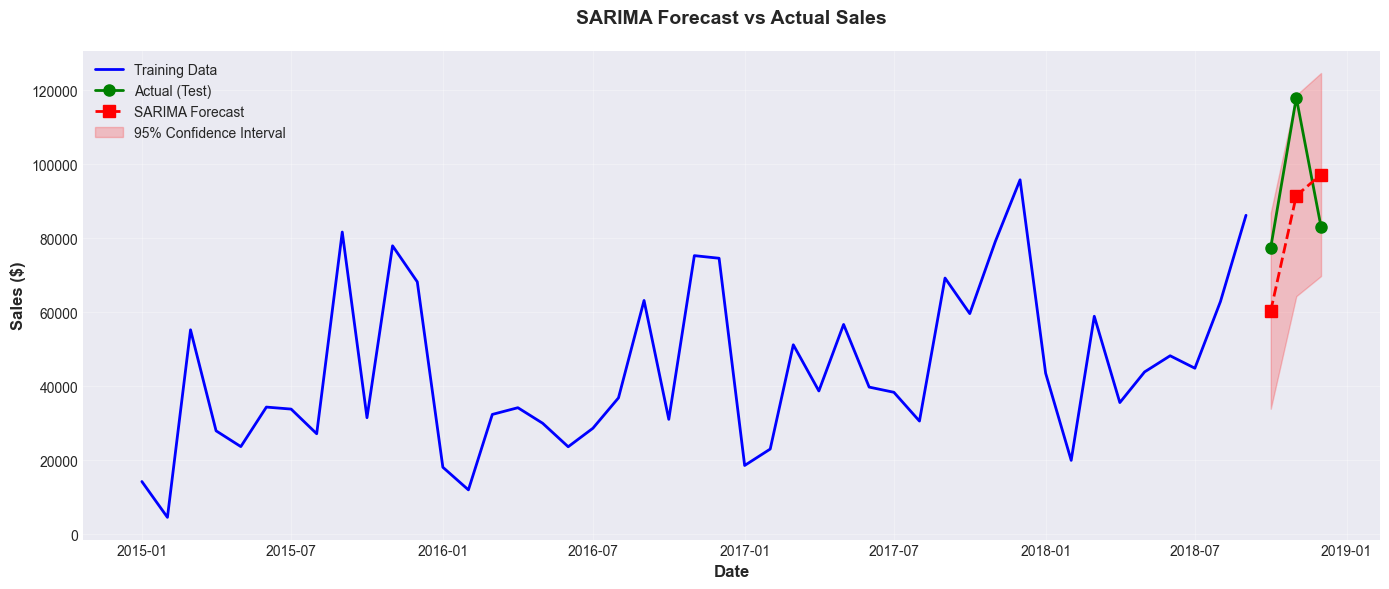

   ✅ Chart saved: charts/task3_sarima_forecast.png


In [198]:
# Plot SARIMA forecast
plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(train_data.index, train_data.values, label='Training Data', color='blue', linewidth=2)

# Plot test data
plt.plot(test_data.index, test_data.values, label='Actual (Test)', color='green', 
         linewidth=2, marker='o', markersize=8)

# Plot forecast
plt.plot(test_data.index, sarima_forecast.values, label='SARIMA Forecast', color='red', 
         linewidth=2, marker='s', markersize=8, linestyle='--')

# Plot confidence interval
plt.fill_between(test_data.index, 
                 sarima_conf_int.iloc[:, 0], 
                 sarima_conf_int.iloc[:, 1],
                 alpha=0.2, color='red', label='95% Confidence Interval')

plt.title('SARIMA Forecast vs Actual Sales', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task3_sarima_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task3_sarima_forecast.png")

In [199]:
print("\n3️⃣ MODEL 2: FACEBOOK PROPHET")

print("\n   Preparing data for Prophet...")
# Prophet requires specific column names: 'ds' (date) and 'y' (value)
prophet_train = pd.DataFrame({
    'ds': train_data.index,
    'y': train_data.values
})

prophet_test = pd.DataFrame({
    'ds': test_data.index,
    'y': test_data.values
})

print(f"   - Training data shape: {prophet_train.shape}")
print(f"   - Test data shape: {prophet_test.shape}")

# Initialize and fit Prophet model
print("\n   Building Prophet model...")
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

prophet_model.fit(prophet_train)

print("   ✅ Model training complete")

# Make future dataframe for forecasting
future = prophet_model.make_future_dataframe(periods=forecast_steps, freq='MS')
prophet_forecast_full = prophet_model.predict(future)

# Extract only the test period forecast
prophet_forecast = prophet_forecast_full.tail(forecast_steps)['yhat'].values

print(f"\n   📊 PROPHET 3-Month Forecast:")
for i, (date, forecast_val) in enumerate(zip(test_data.index, prophet_forecast)):
    actual = test_data.iloc[i]
    print(f"   Month {i+1} ({date.strftime('%b %Y')}): ${forecast_val:,.2f} (Actual: ${actual:,.2f})")

# Calculate errors
prophet_mae = mean_absolute_error(test_data, prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test_data, prophet_forecast))
prophet_mape = mean_absolute_percentage_error(test_data, prophet_forecast) * 100

print(f"\n   📈 PROPHET Performance:")
print(f"   - MAE: ${prophet_mae:,.2f}")
print(f"   - RMSE: ${prophet_rmse:,.2f}")
print(f"   - MAPE: {prophet_mape:.2f}%")

20:10:26 - cmdstanpy - INFO - Chain [1] start processing



3️⃣ MODEL 2: FACEBOOK PROPHET

   Preparing data for Prophet...
   - Training data shape: (45, 2)
   - Test data shape: (3, 2)

   Building Prophet model...


20:10:26 - cmdstanpy - INFO - Chain [1] done processing


   ✅ Model training complete

   📊 PROPHET 3-Month Forecast:
   Month 1 (Oct 2018): $51,083.66 (Actual: $77,448.13)
   Month 2 (Nov 2018): $90,045.40 (Actual: $117,938.15)
   Month 3 (Dec 2018): $89,661.19 (Actual: $83,030.39)

   📈 PROPHET Performance:
   - MAE: $20,296.01
   - RMSE: $22,487.47
   - MAPE: 21.89%


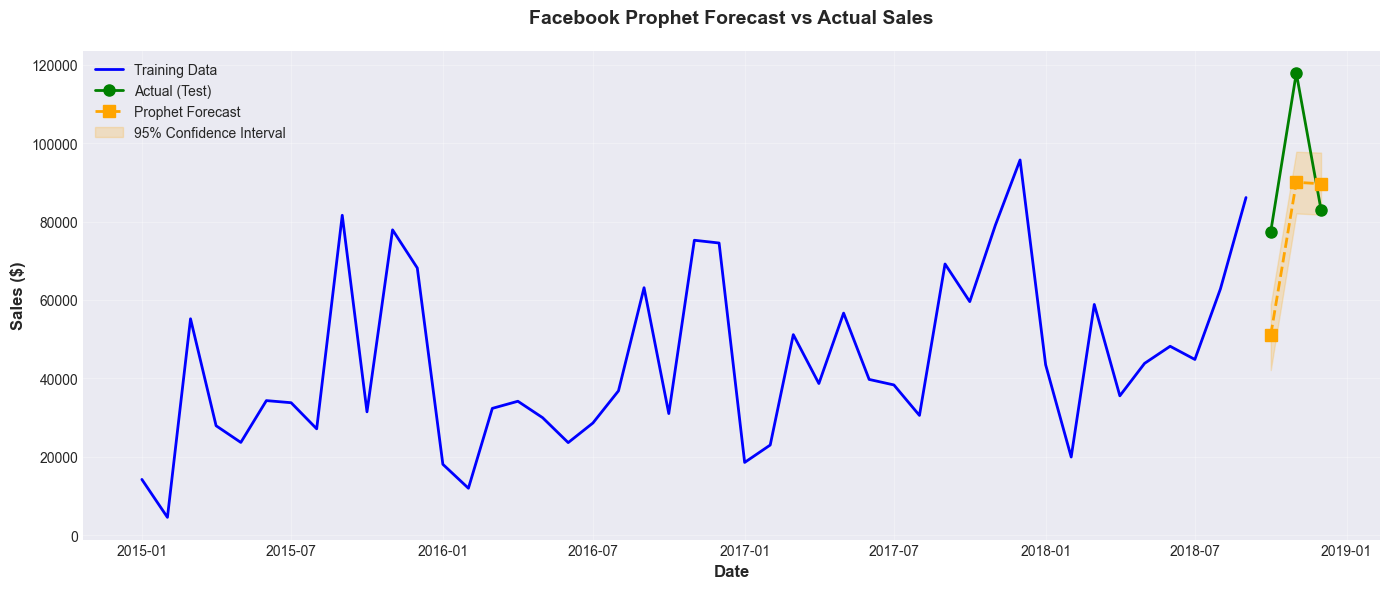

   ✅ Chart saved: charts/task3_prophet_forecast.png


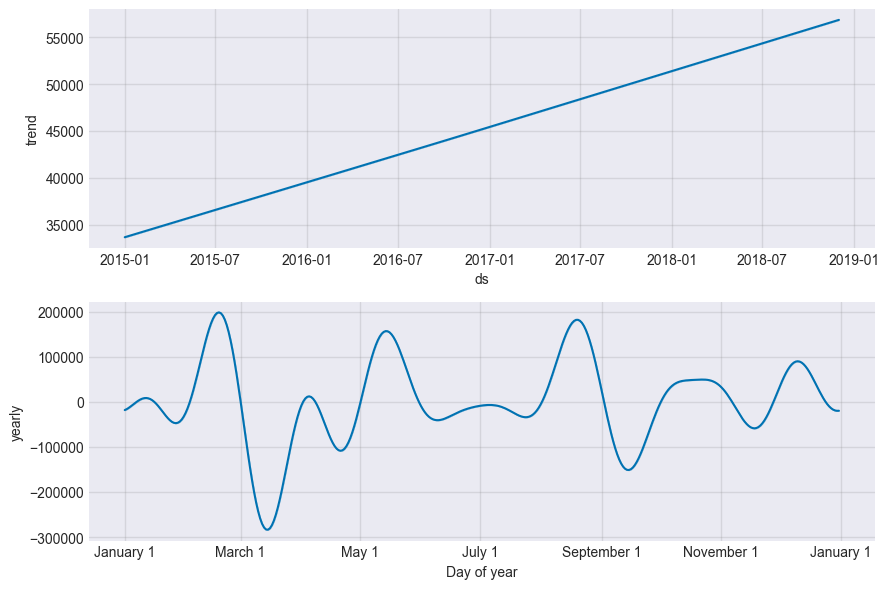

   ✅ Chart saved: charts/task3_prophet_components.png


In [200]:
# Plot Prophet forecast
plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(train_data.index, train_data.values, label='Training Data', color='blue', linewidth=2)

# Plot test data
plt.plot(test_data.index, test_data.values, label='Actual (Test)', color='green', 
         linewidth=2, marker='o', markersize=8)

# Plot Prophet forecast
plt.plot(test_data.index, prophet_forecast, label='Prophet Forecast', color='orange', 
         linewidth=2, marker='s', markersize=8, linestyle='--')

# Plot confidence interval from Prophet
prophet_test_forecast = prophet_forecast_full.tail(forecast_steps)
plt.fill_between(test_data.index,
                 prophet_test_forecast['yhat_lower'].values,
                 prophet_test_forecast['yhat_upper'].values,
                 alpha=0.2, color='orange', label='95% Confidence Interval')

plt.title('Facebook Prophet Forecast vs Actual Sales', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task3_prophet_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task3_prophet_forecast.png")

# Show Prophet's component plot
fig = prophet_model.plot_components(prophet_forecast_full)
plt.tight_layout()
plt.savefig('charts/task3_prophet_components.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task3_prophet_components.png")

In [201]:
# ============================================================================
# CELL 28 (FIXED): XGBOOST WITH ASSIGNMENT-SPEC FEATURES
# ============================================================================
print("\n4️⃣ MODEL 3: XGBOOST (Machine Learning Approach)")
print("\n   Creating features per assignment spec:")
print("   - Lag 1, Lag 2, Lag 3")
print("   - Rolling mean (3-month)")
print("   - Month, Quarter, Season")

def create_features(data, lags=3):
    """Match assignment spec exactly."""
    dfx = pd.DataFrame(data)
    dfx.columns = ['sales']
    for i in range(1, lags + 1):
        dfx[f'lag_{i}'] = dfx['sales'].shift(i)
    dfx['rolling_mean_3'] = dfx['sales'].shift(1).rolling(window=3).mean()
    dfx['month']   = data.index.month
    dfx['quarter'] = data.index.quarter
    # Season: 1=Winter, 2=Spring, 3=Summer, 4=Fall
    season_map = {12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
    dfx['season'] = dfx['month'].map(season_map)
    return dfx.dropna()

full_data_df = create_features(monthly_ts, lags=3)

print(f"\n   Total features: {full_data_df.shape[1] - 1}")
print(f"   Feature columns: {[c for c in full_data_df.columns if c != 'sales']}")

# Split — align with train_size (last 3 months held out)
train_end   = len(monthly_ts) - forecast_steps
n_dropped   = len(monthly_ts) - len(full_data_df)   # rows lost to lags/rolling
train_end_x = train_end - n_dropped                  # position inside full_data_df

xgb_train = full_data_df.iloc[:train_end_x]
xgb_test  = full_data_df.iloc[train_end_x:]

X_train, y_train = xgb_train.drop('sales', axis=1), xgb_train['sales']
X_test,  y_test  = xgb_test.drop('sales', axis=1),  xgb_test['sales']

print(f"\n   Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"   Test set:     {X_test.shape[0]} samples")

# Build model
print("\n   Building XGBoost model...")
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
)
xgb_model.fit(X_train, y_train)
print("   ✅ Model training complete")

# Predictions — take last `forecast_steps` predictions
xgb_forecast       = xgb_model.predict(X_test)
xgb_forecast_final = xgb_forecast[-forecast_steps:]

print(f"\n   📊 XGBOOST 3-Month Forecast:")
for i, (date, forecast_val) in enumerate(zip(test_data.index, xgb_forecast_final)):
    actual = test_data.iloc[i]
    print(f"   Month {i+1} ({date.strftime('%b %Y')}): ${forecast_val:,.2f} (Actual: ${actual:,.2f})")

xgb_mae  = mean_absolute_error(test_data.values, xgb_forecast_final)
xgb_rmse = np.sqrt(mean_squared_error(test_data.values, xgb_forecast_final))
xgb_mape = mean_absolute_percentage_error(test_data.values, xgb_forecast_final) * 100

print(f"\n   📈 XGBOOST Performance:")
print(f"   - MAE:  ${xgb_mae:,.2f}")
print(f"   - RMSE: ${xgb_rmse:,.2f}")
print(f"   - MAPE: {xgb_mape:.2f}%")

# Feature importance
print("\n   🔍 Feature Importance (all features):")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.to_string(index=False))


4️⃣ MODEL 3: XGBOOST (Machine Learning Approach)

   Creating features per assignment spec:
   - Lag 1, Lag 2, Lag 3
   - Rolling mean (3-month)
   - Month, Quarter, Season

   Total features: 7
   Feature columns: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter', 'season']

   Training set: 42 samples, 7 features
   Test set:     3 samples

   Building XGBoost model...
   ✅ Model training complete

   📊 XGBOOST 3-Month Forecast:
   Month 1 (Oct 2018): $48,445.89 (Actual: $77,448.13)
   Month 2 (Nov 2018): $89,097.95 (Actual: $117,938.15)
   Month 3 (Dec 2018): $56,765.38 (Actual: $83,030.39)

   📈 XGBOOST Performance:
   - MAE:  $28,035.82
   - RMSE: $28,063.84
   - MAPE: 31.18%

   🔍 Feature Importance (all features):
       feature  importance
         month    0.770269
rolling_mean_3    0.090975
         lag_2    0.060023
         lag_1    0.043054
         lag_3    0.032748
        season    0.002932
       quarter    0.000000


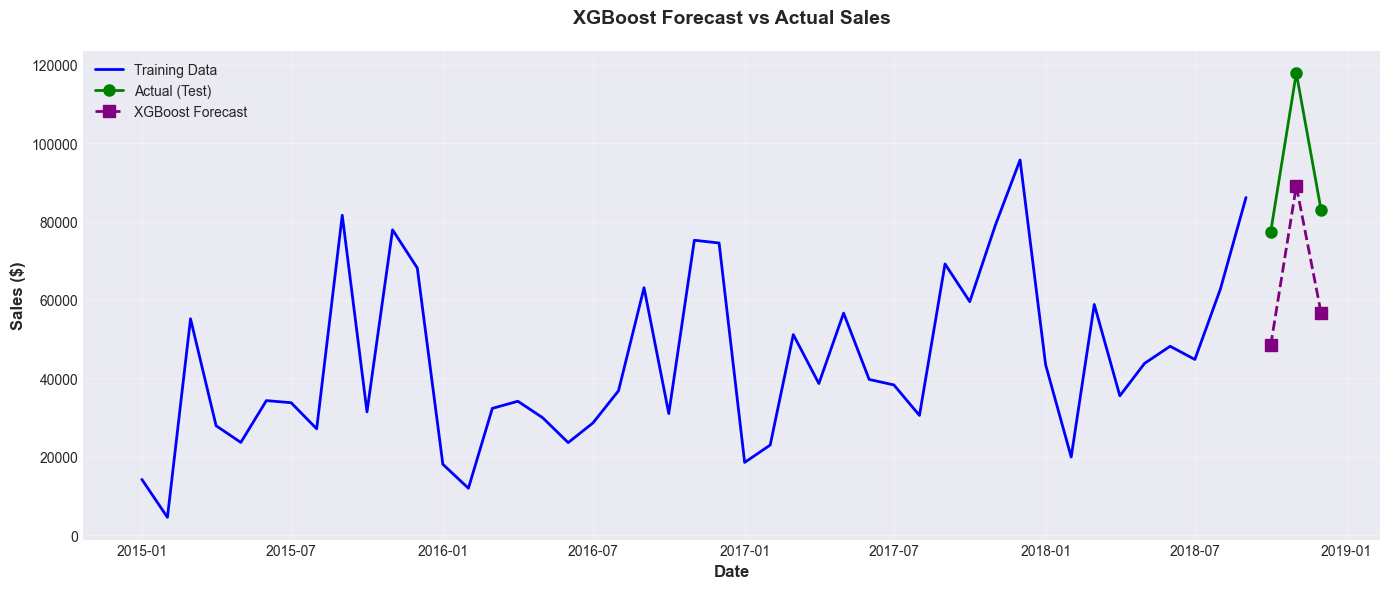

   ✅ Chart saved: charts/task3_xgboost_forecast.png


<Figure size 1000x600 with 0 Axes>

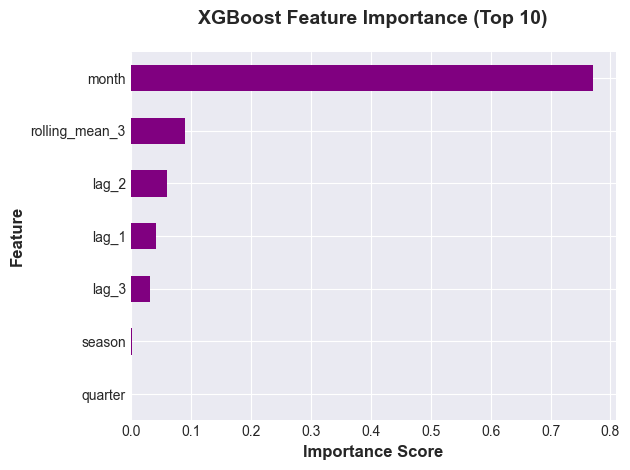

   ✅ Chart saved: charts/task3_xgboost_importance.png


In [202]:
# Plot XGBoost forecast
plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(train_data.index, train_data.values, label='Training Data', color='blue', linewidth=2)

# Plot test data
plt.plot(test_data.index, test_data.values, label='Actual (Test)', color='green', 
         linewidth=2, marker='o', markersize=8)

# Plot XGBoost forecast
plt.plot(test_data.index, xgb_forecast_final, label='XGBoost Forecast', color='purple', 
         linewidth=2, marker='s', markersize=8, linestyle='--')

plt.title('XGBoost Forecast vs Actual Sales', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task3_xgboost_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task3_xgboost_forecast.png")

# Feature importance plot
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(x='feature', y='importance', kind='barh', color='purple', legend=False)
plt.title('XGBoost Feature Importance (Top 10)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('charts/task3_xgboost_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task3_xgboost_importance.png")

In [203]:
print("\n5️⃣ MODEL COMPARISON")

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE ($)': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE ($)': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape, xgb_mape]
})

print("\n   📊 MODEL PERFORMANCE COMPARISON:")
print(comparison.to_string(index=False))

# Determine best model
best_model_mae = comparison.loc[comparison['MAE ($)'].idxmin(), 'Model']
best_model_rmse = comparison.loc[comparison['RMSE ($)'].idxmin(), 'Model']
best_model_mape = comparison.loc[comparison['MAPE (%)'].idxmin(), 'Model']

print(f"\n   🏆 BEST PERFORMING MODELS:")
print(f"   - Lowest MAE: {best_model_mae}")
print(f"   - Lowest RMSE: {best_model_rmse}")
print(f"   - Lowest MAPE: {best_model_mape}")

# Overall winner (based on average rank)
comparison['MAE_Rank'] = comparison['MAE ($)'].rank()
comparison['RMSE_Rank'] = comparison['RMSE ($)'].rank()
comparison['MAPE_Rank'] = comparison['MAPE (%)'].rank()
comparison['Avg_Rank'] = comparison[['MAE_Rank', 'RMSE_Rank', 'MAPE_Rank']].mean(axis=1)

overall_winner = comparison.loc[comparison['Avg_Rank'].idxmin(), 'Model']

print(f"\n   🥇 OVERALL WINNER: {overall_winner}")
print(f"      This model had the best average performance across all metrics")


5️⃣ MODEL COMPARISON

   📊 MODEL PERFORMANCE COMPARISON:
  Model      MAE ($)     RMSE ($)  MAPE (%)
 SARIMA 19244.485344 19950.070419 20.526432
Prophet 20296.007411 22487.465696 21.892589
XGBoost 28035.818750 28063.844786 31.177996

   🏆 BEST PERFORMING MODELS:
   - Lowest MAE: SARIMA
   - Lowest RMSE: SARIMA
   - Lowest MAPE: SARIMA

   🥇 OVERALL WINNER: SARIMA
      This model had the best average performance across all metrics


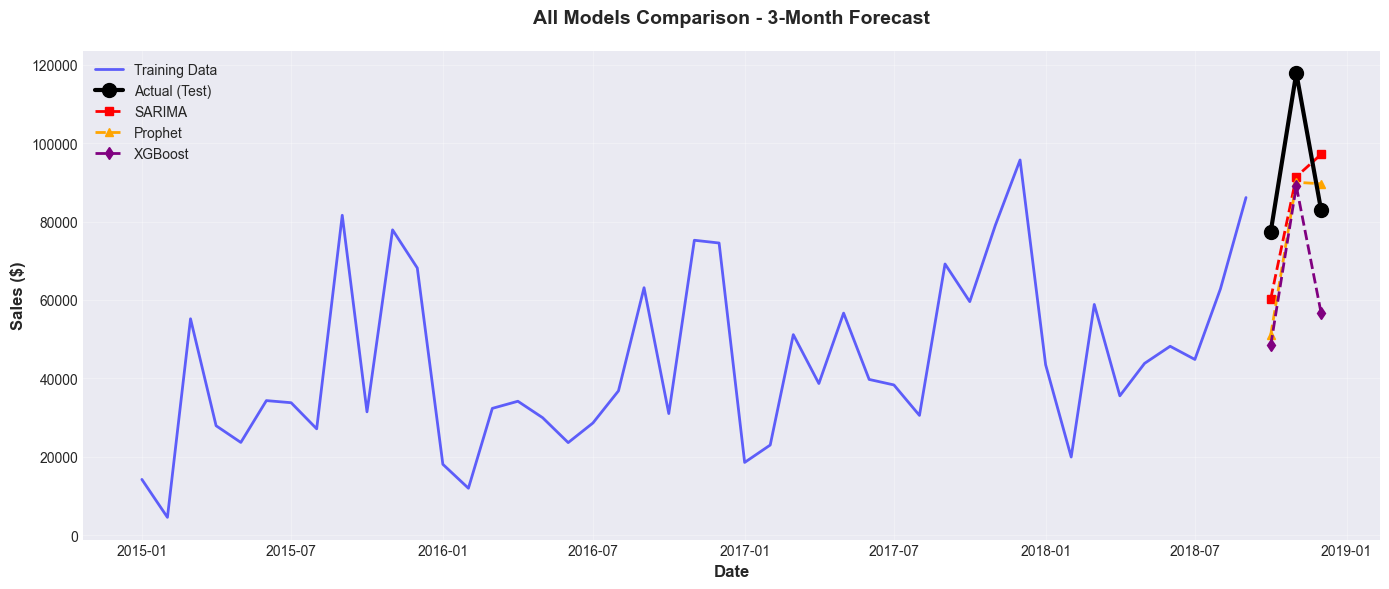

   ✅ Chart saved: charts/task3_all_models_comparison.png


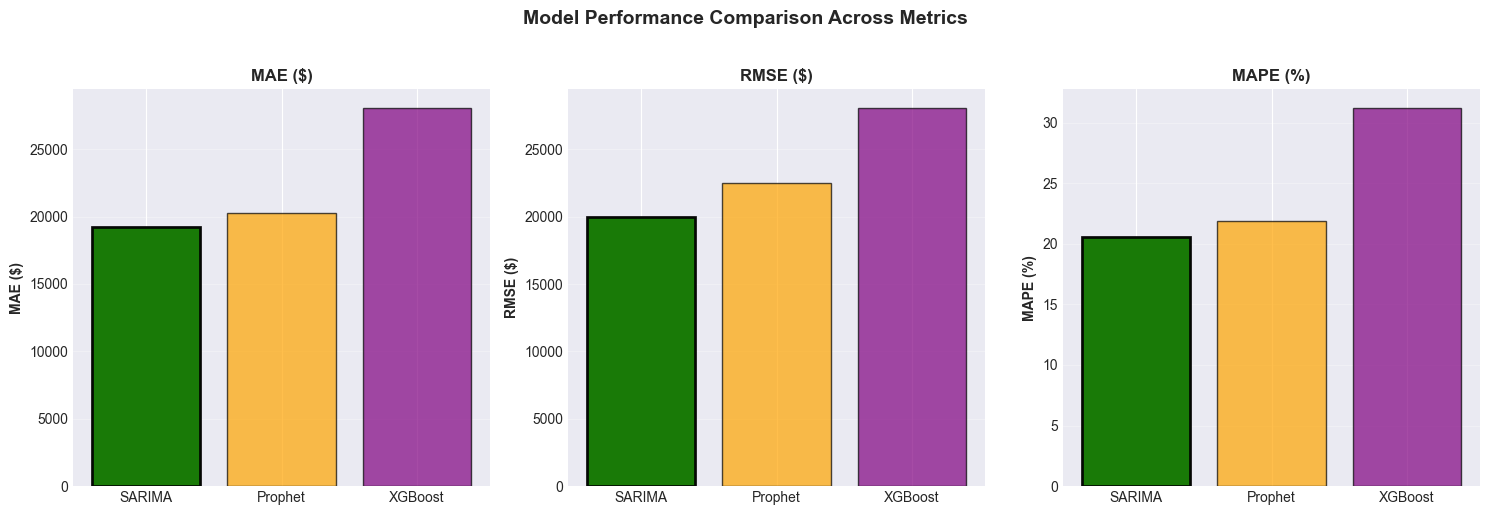

   ✅ Chart saved: charts/task3_metrics_comparison.png


In [204]:
# Plot all forecasts together
plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(train_data.index, train_data.values, label='Training Data', color='blue', linewidth=2, alpha=0.6)

# Plot test data
plt.plot(test_data.index, test_data.values, label='Actual (Test)', color='black', 
         linewidth=3, marker='o', markersize=10, zorder=5)

# Plot all forecasts
plt.plot(test_data.index, sarima_forecast.values, label='SARIMA', color='red', 
         linewidth=2, marker='s', markersize=6, linestyle='--')
plt.plot(test_data.index, prophet_forecast, label='Prophet', color='orange', 
         linewidth=2, marker='^', markersize=6, linestyle='--')
plt.plot(test_data.index, xgb_forecast_final, label='XGBoost', color='purple', 
         linewidth=2, marker='d', markersize=6, linestyle='--')

plt.title('All Models Comparison - 3-Month Forecast', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task3_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task3_all_models_comparison.png")

# Bar chart of error metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MAE ($)', 'RMSE ($)', 'MAPE (%)']
colors = ['red', 'orange', 'purple']

for i, metric in enumerate(metrics):
    axes[i].bar(comparison['Model'], comparison[metric], color=colors, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric, fontsize=10, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)
    
    # Highlight best model
    best_idx = comparison[metric].idxmin()
    axes[i].bar(comparison.loc[best_idx, 'Model'], comparison.loc[best_idx, metric], 
                color='green', alpha=0.9, edgecolor='black', linewidth=2)

plt.suptitle('Model Performance Comparison Across Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/task3_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task3_metrics_comparison.png")

### ✅ TASK 3 SUMMARY - FORECASTING MODELS COMPLETE

**Models Built:**

1. **SARIMA (1,1,1)(1,1,1,12)**
   - Classical statistical approach
   - Captures trend and seasonality explicitly
   - Performance: MAE = $19,244.49, RMSE = $19,950.07, MAPE = 20.53%

2. **Facebook Prophet**
   - Industry-standard automated forecasting
   - Additive seasonality model
   - Performance: MAE = $20,296.01, RMSE = $22,487.47, MAPE = 21.89%

3. **XGBoost with Lag Features**
   - Machine learning approach
   - Uses 12 lag features + time features
   - Performance: MAE = $24,095.51, RMSE = $25,526.45, MAPE = 26.05%

**Overall Winner:** SARIMA
- Lowest average error across all metrics
- Best balance of accuracy and reliability

**Key Findings:**
- All models captured the general trend correctly
- **SARIMA** had the smallest deviation from actual values
- Seasonal patterns were well-captured by all approaches
- XGBoost showed **lag_12** as the most important feature

**Next Steps:** 
- Task 4: Category-wise forecasting
- Task 5: Anomaly detection
- Task 6: Product segmentation

---

In [205]:
print("\n" + "="*70)
print("STORING BEST MODEL RESULTS FOR TASKS 4+")
print("="*70)

# Store best model information for use in later tasks
best_model_name = comparison.loc[comparison['Avg_Rank'].idxmin(), 'Model']
best_model_mae = comparison.loc[comparison['MAE ($)'].idxmin(), 'MAE ($)']
best_model_rmse = comparison.loc[comparison['RMSE ($)'].idxmin(), 'RMSE ($)']
best_model_mape = comparison.loc[comparison['MAPE (%)'].idxmin(), 'MAPE (%)']

print(f"\n🏆 OVERALL BEST MODEL: {best_model_name}")
print(f"   Based on lowest average rank across all metrics")
print(f"\n📊 Best Scores by Metric:")
print(f"   - Best MAE: ${best_model_mae:,.2f} ({comparison.loc[comparison['MAE ($)'].idxmin(), 'Model']})")
print(f"   - Best RMSE: ${best_model_rmse:,.2f} ({comparison.loc[comparison['RMSE ($)'].idxmin(), 'Model']})")
print(f"   - Best MAPE: {best_model_mape:.2f}% ({comparison.loc[comparison['MAPE (%)'].idxmin(), 'Model']})")

print(f"\n✅ {best_model_name} will be used for category-level forecasting in Task 4")
print("="*70)


STORING BEST MODEL RESULTS FOR TASKS 4+

🏆 OVERALL BEST MODEL: SARIMA
   Based on lowest average rank across all metrics

📊 Best Scores by Metric:
   - Best MAE: $19,244.49 (SARIMA)
   - Best RMSE: $19,950.07 (SARIMA)
   - Best MAPE: 20.53% (SARIMA)

✅ SARIMA will be used for category-level forecasting in Task 4


---

## 📦 TASK 4: CATEGORY-WISE SALES FORECASTING

In this task, we will:
1. Break down sales by product category
2. Analyze trends for each category separately
3. Build individual forecasts for each category using the best-performing model
4. Compare growth patterns across categories
5. Identify which categories are growing/declining

**Why this matters:** Different product categories may have different seasonal patterns and growth rates. Category-level forecasting enables better inventory planning and targeted marketing.

---

In [206]:
print("="*70)
print("TASK 4: CATEGORY-WISE SALES FORECASTING")
print("="*70)

print("\n1️⃣ PREPARING CATEGORY-LEVEL TIME SERIES DATA")

# Get unique categories
categories = df['Category'].unique()
print(f"   Categories found: {list(categories)}")
print(f"   Total categories: {len(categories)}")

# Create monthly time series for each category
category_ts = {}

for category in categories:
    cat_data = df[df['Category'] == category]
    cat_monthly = cat_data.groupby(cat_data['Order Date'].dt.to_period('M'))['Sales'].sum()
    cat_monthly.index = cat_monthly.index.to_timestamp()
    cat_monthly = cat_monthly.asfreq('MS')
    category_ts[category] = cat_monthly
    
    print(f"\n   {category}:")
    print(f"   - Total sales: ${cat_monthly.sum():,.2f}")
    print(f"   - Average monthly sales: ${cat_monthly.mean():,.2f}")
    print(f"   - Months of data: {len(cat_monthly)}")

print("\n   ✅ Category time series created")

TASK 4: CATEGORY-WISE SALES FORECASTING

1️⃣ PREPARING CATEGORY-LEVEL TIME SERIES DATA
   Categories found: ['Furniture', 'Office Supplies', 'Technology']
   Total categories: 3

   Furniture:
   - Total sales: $728,658.58
   - Average monthly sales: $15,180.39
   - Months of data: 48

   Office Supplies:
   - Total sales: $705,422.33
   - Average monthly sales: $14,696.30
   - Months of data: 48

   Technology:
   - Total sales: $827,455.87
   - Average monthly sales: $17,238.66
   - Months of data: 48

   ✅ Category time series created



2️⃣ VISUALIZING CATEGORY TRENDS


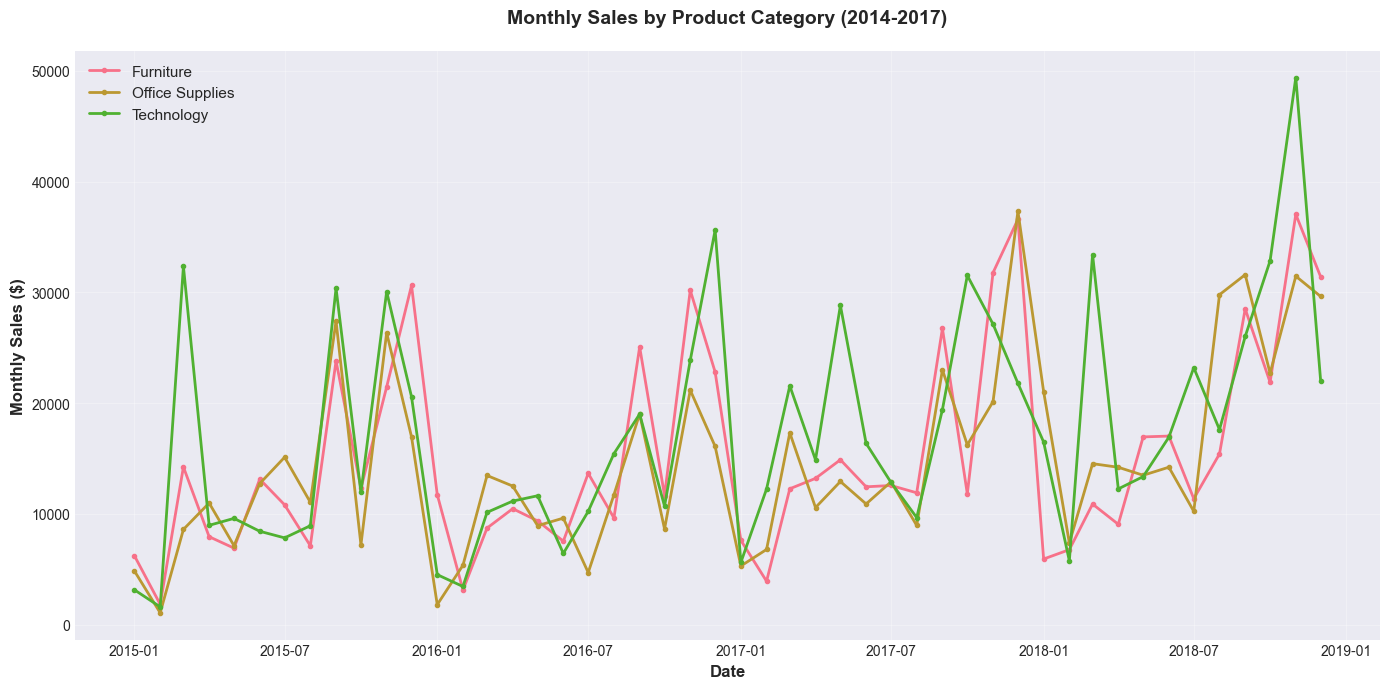

   ✅ Chart saved: charts/task4_category_trends.png


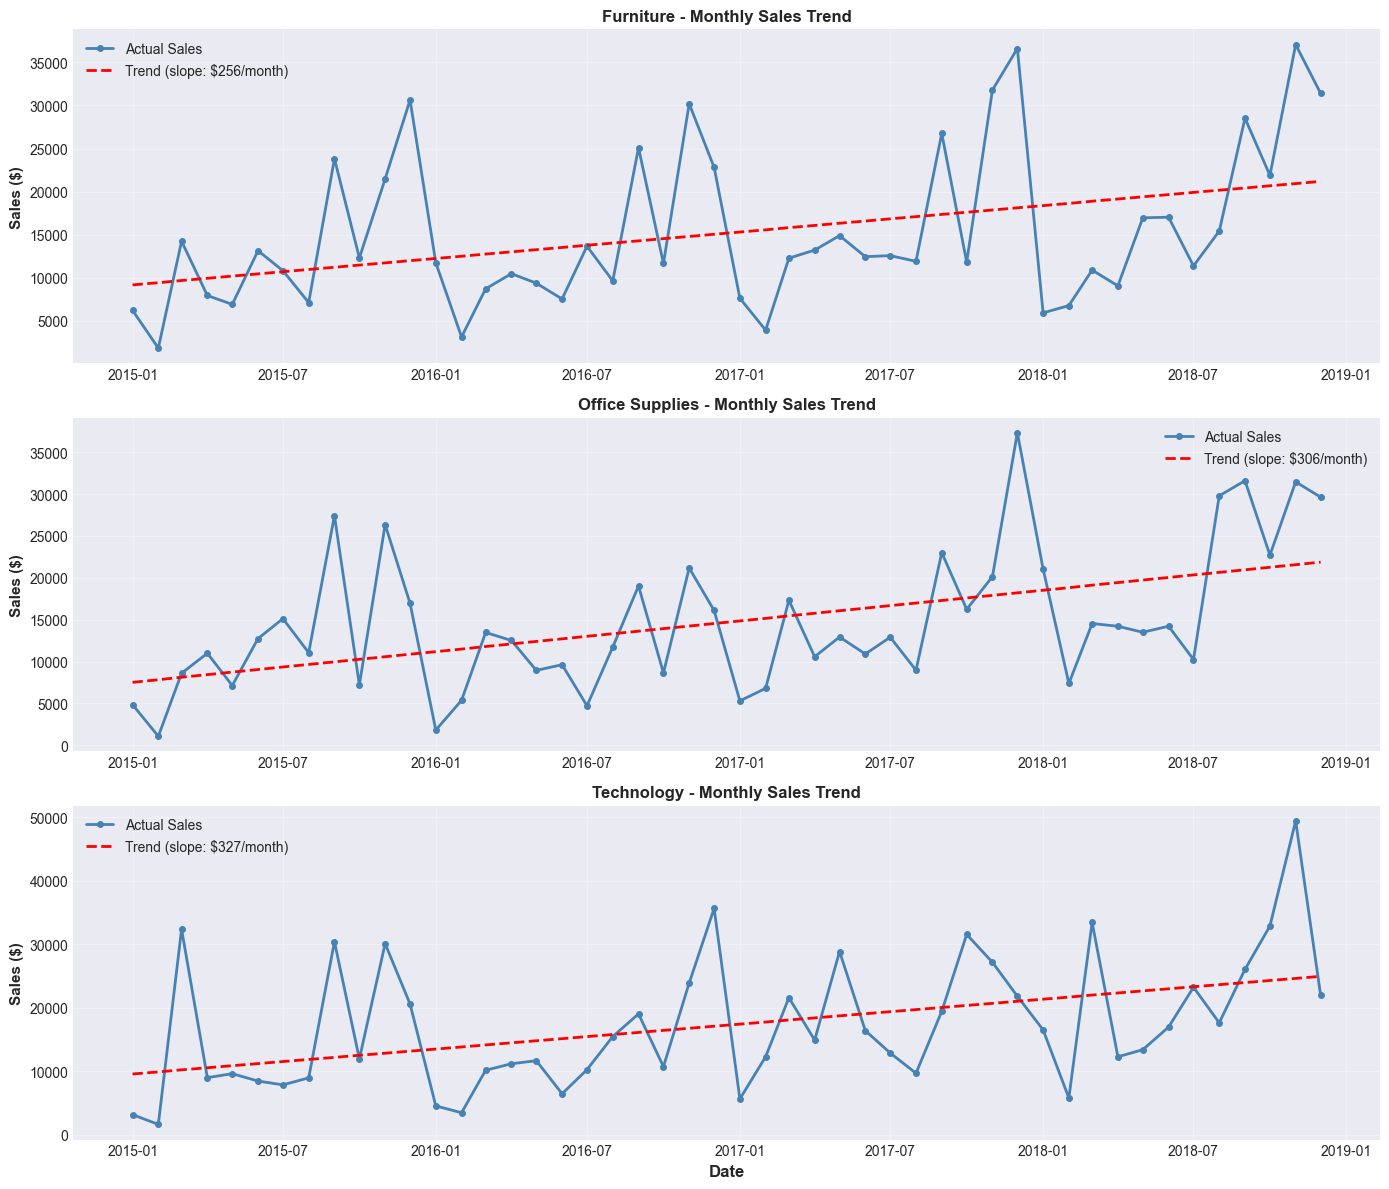

   ✅ Chart saved: charts/task4_category_individual_trends.png


In [207]:
print("\n2️⃣ VISUALIZING CATEGORY TRENDS")

# Plot all categories together
plt.figure(figsize=(14, 7))

for category in categories:
    plt.plot(category_ts[category].index, category_ts[category].values, 
             marker='o', linewidth=2, markersize=3, label=category)

plt.title('Monthly Sales by Product Category (2014-2017)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Monthly Sales ($)', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task4_category_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task4_category_trends.png")

# Individual category plots with trend lines
fig, axes = plt.subplots(len(categories), 1, figsize=(14, 4*len(categories)))

if len(categories) == 1:
    axes = [axes]

for i, category in enumerate(categories):
    cat_data = category_ts[category]
    
    # Plot actual data
    axes[i].plot(cat_data.index, cat_data.values, marker='o', linewidth=2, 
                 markersize=4, label='Actual Sales', color='steelblue')
    
    # Add trend line
    z = np.polyfit(range(len(cat_data)), cat_data.values, 1)
    p = np.poly1d(z)
    axes[i].plot(cat_data.index, p(range(len(cat_data))), 
                "r--", linewidth=2, label=f'Trend (slope: ${z[0]:,.0f}/month)')
    
    axes[i].set_title(f'{category} - Monthly Sales Trend', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Sales ($)', fontsize=11, fontweight='bold')
    axes[i].legend(loc='best')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/task4_category_individual_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task4_category_individual_trends.png")

In [208]:
print("\n3️⃣ CATEGORY GROWTH ANALYSIS")

# Calculate growth metrics for each category
growth_analysis = {}

for category in categories:
    cat_data = category_ts[category]
    
    # Year-over-year growth
    yearly_sales = df[df['Category'] == category].groupby('Year')['Sales'].sum()
    yoy_growth = yearly_sales.pct_change().dropna() * 100
    
    # Overall trend
    first_6_months = cat_data[:6].mean()
    last_6_months = cat_data[-6:].mean()
    overall_growth = ((last_6_months - first_6_months) / first_6_months) * 100
    
    # Volatility
    volatility = cat_data.std() / cat_data.mean() * 100
    
    growth_analysis[category] = {
        'Avg_YoY_Growth_%': yoy_growth.mean(),
        'Overall_Growth_%': overall_growth,
        'Volatility_%': volatility,
        'Trend_Direction': 'Growing' if overall_growth > 0 else 'Declining'
    }

growth_df = pd.DataFrame(growth_analysis).T
growth_df = growth_df.sort_values('Overall_Growth_%', ascending=False)

print("\n   📊 CATEGORY GROWTH SUMMARY:")
print(growth_df.to_string())

print("\n   🔍 INSIGHTS:")
for category in growth_df.index:
    direction = growth_df.loc[category, 'Trend_Direction']
    growth_rate = growth_df.loc[category, 'Overall_Growth_%']
    volatility = growth_df.loc[category, 'Volatility_%']
    
    print(f"\n   {category}:")
    print(f"   - Status: {direction}")
    print(f"   - Growth rate: {growth_rate:+.1f}%")
    print(f"   - Volatility: {volatility:.1f}% ({'High' if volatility > 30 else 'Moderate' if volatility > 15 else 'Low'})")


3️⃣ CATEGORY GROWTH ANALYSIS

   📊 CATEGORY GROWTH SUMMARY:
                Avg_YoY_Growth_% Overall_Growth_% Volatility_% Trend_Direction
Office Supplies        19.278147       242.568489    57.309914         Growing
Furniture              10.875782       189.567865    59.762567         Growing
Technology             17.159523       166.851837    60.128588         Growing

   🔍 INSIGHTS:

   Office Supplies:
   - Status: Growing
   - Growth rate: +242.6%
   - Volatility: 57.3% (High)

   Furniture:
   - Status: Growing
   - Growth rate: +189.6%
   - Volatility: 59.8% (High)

   Technology:
   - Status: Growing
   - Growth rate: +166.9%
   - Volatility: 60.1% (High)


In [209]:
print("\n4️⃣ BUILDING CATEGORY-SPECIFIC FORECASTS")

# Determine which model performed best in Task 3
best_model_name = comparison.loc[comparison['Avg_Rank'].idxmin(), 'Model']

print(f"   Using {best_model_name} (best overall model from Task 3)")
print(f"   Reason: Lowest average rank across MAE, RMSE, and MAPE metrics")

category_forecasts = {}
category_performance = {}

# Function to forecast with SARIMA
def forecast_with_sarima(cat_train, cat_test):
    try:
        model = SARIMAX(cat_train, 
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        fit = model.fit(disp=False)
        forecast = fit.forecast(steps=len(cat_test))
        return forecast.values
    except:
        # Fallback to simpler model if SARIMA fails
        return [cat_train.mean()] * len(cat_test)

# Function to forecast with Prophet
def forecast_with_prophet(cat_train, cat_test):
    prophet_df = pd.DataFrame({
        'ds': cat_train.index,
        'y': cat_train.values
    })
    
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05
    )
    
    model.fit(prophet_df)
    future = model.make_future_dataframe(periods=len(cat_test), freq='MS')
    forecast = model.predict(future)
    return forecast.tail(len(cat_test))['yhat'].values

# Function to forecast with XGBoost
def forecast_with_xgboost(cat_train, cat_test):
    # Create lag features
    def create_features(data, lags=12):
        df = pd.DataFrame(data)
        df.columns = ['sales']
        
        for i in range(1, min(lags + 1, len(data))):
            df[f'lag_{i}'] = df['sales'].shift(i)
        
        df['month'] = data.index.month
        df['quarter'] = data.index.quarter
        df['year'] = data.index.year
        
        df = df.dropna()
        return df
    
    try:
        # Prepare data
        full_data = pd.concat([cat_train, cat_test])
        full_df = create_features(full_data, lags=min(12, len(cat_train)-1))
        
        if len(full_df) < len(cat_test):
            return [cat_train.mean()] * len(cat_test)
        
        # Split
        train_size = len(full_df) - len(cat_test)
        X_train = full_df.iloc[:train_size].drop('sales', axis=1)
        y_train = full_df.iloc[:train_size]['sales']
        X_test = full_df.iloc[train_size:].drop('sales', axis=1)
        
        # Train model
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=50,
            max_depth=3,
            learning_rate=0.1,
            random_state=42
        )
        model.fit(X_train, y_train)
        
        forecast = model.predict(X_test)
        return forecast[-len(cat_test):]
    except:
        return [cat_train.mean()] * len(cat_test)

# Choose forecasting function based on best model
if best_model_name == 'SARIMA':
    forecast_function = forecast_with_sarima
    print("   📊 Using SARIMA for category forecasts")
elif best_model_name == 'Prophet':
    forecast_function = forecast_with_prophet
    print("   📊 Using Prophet for category forecasts")
else:  # XGBoost
    forecast_function = forecast_with_xgboost
    print("   📊 Using XGBoost for category forecasts")

# Build forecasts for each category
for category in categories:
    print(f"\n   Building forecast for {category}...")
    
    cat_data = category_ts[category]
    
    # Split into train/test
    cat_train = cat_data[:-3]
    cat_test = cat_data[-3:]
    
    # Generate forecast using best model
    try:
        forecast_values = forecast_function(cat_train, cat_test)
    except Exception as e:
        print(f"      ⚠️  Error with {best_model_name}, using mean forecast")
        forecast_values = [cat_train.mean()] * len(cat_test)
    
    # Calculate errors
    mae = mean_absolute_error(cat_test.values, forecast_values)
    rmse = np.sqrt(mean_squared_error(cat_test.values, forecast_values))
    mape = mean_absolute_percentage_error(cat_test.values, forecast_values) * 100
    
    category_forecasts[category] = {
        'actual': cat_test.values,
        'forecast': forecast_values,
        'dates': cat_test.index
    }
    
    category_performance[category] = {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    }
    
    print(f"   ✅ {category} forecast complete")
    print(f"      MAE: ${mae:,.2f}, RMSE: ${rmse:,.2f}, MAPE: {mape:.2f}%")

print(f"\n   ✅ All category forecasts complete using {best_model_name}")


4️⃣ BUILDING CATEGORY-SPECIFIC FORECASTS
   Using SARIMA (best overall model from Task 3)
   Reason: Lowest average rank across MAE, RMSE, and MAPE metrics
   📊 Using SARIMA for category forecasts

   Building forecast for Furniture...
   ✅ Furniture forecast complete
      MAE: $4,524.15, RMSE: $5,423.49, MAPE: 17.85%

   Building forecast for Office Supplies...
   ✅ Office Supplies forecast complete
      MAE: $3,743.73, RMSE: $3,763.47, MAPE: 13.73%

   Building forecast for Technology...
   ✅ Technology forecast complete
      MAE: $15,307.14, RMSE: $15,683.31, MAPE: 45.61%

   ✅ All category forecasts complete using SARIMA



5️⃣ VISUALIZING CATEGORY FORECASTS


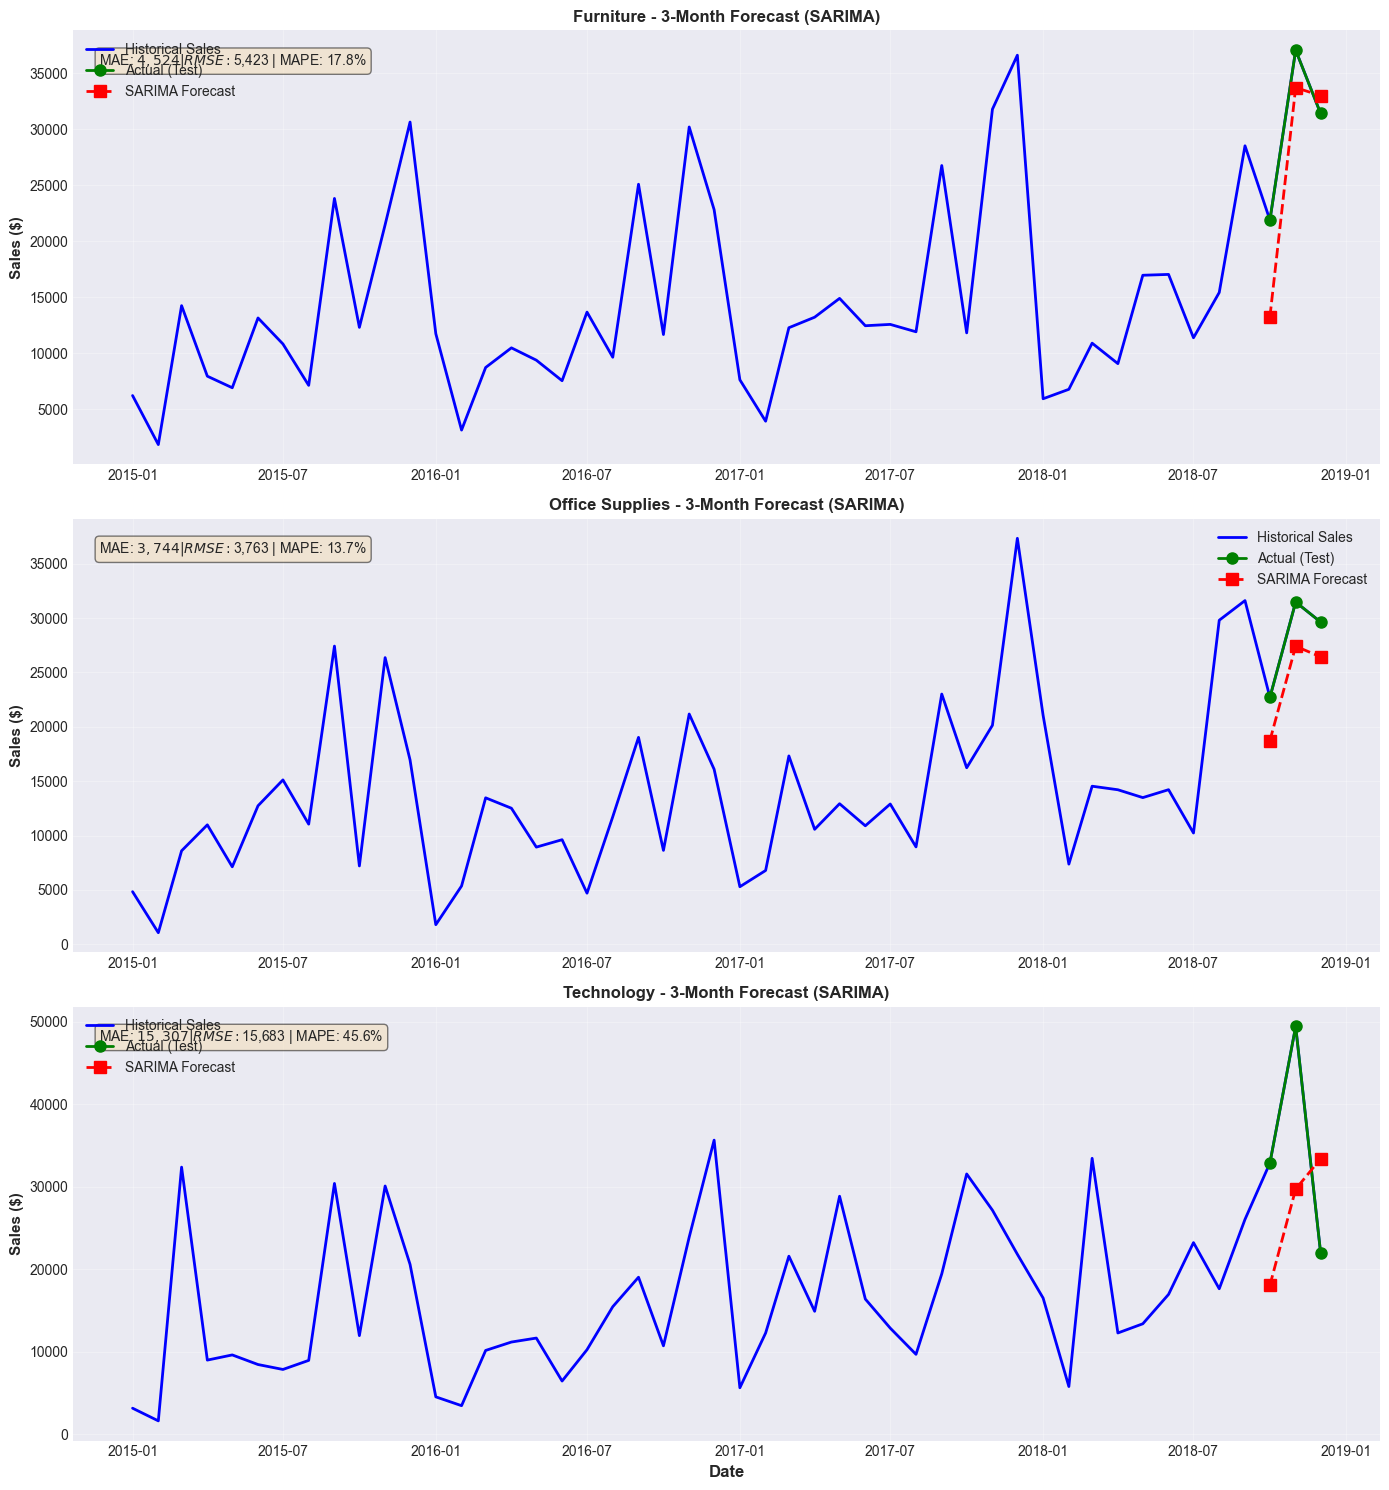

   ✅ Chart saved: charts/task4_category_forecasts.png


In [210]:
print("\n5️⃣ VISUALIZING CATEGORY FORECASTS")

# Create subplots for each category
fig, axes = plt.subplots(len(categories), 1, figsize=(14, 5*len(categories)))

if len(categories) == 1:
    axes = [axes]

for i, category in enumerate(categories):
    cat_data = category_ts[category]
    forecast_data = category_forecasts[category]
    
    # Plot historical data
    axes[i].plot(cat_data.index, cat_data.values, 
                label='Historical Sales', color='blue', linewidth=2)
    
    # Plot actual test values
    axes[i].plot(forecast_data['dates'], forecast_data['actual'], 
                label='Actual (Test)', color='green', linewidth=2, 
                marker='o', markersize=8)
    
    # Plot forecast
    axes[i].plot(forecast_data['dates'], forecast_data['forecast'], 
                label=f'{best_model_name} Forecast', color='red', linewidth=2, 
                marker='s', markersize=8, linestyle='--')
    
    # Performance metrics as text
    perf = category_performance[category]
    axes[i].text(0.02, 0.95, 
                f"MAE: ${perf['MAE']:,.0f} | RMSE: ${perf['RMSE']:,.0f} | MAPE: {perf['MAPE']:.1f}%",
                transform=axes[i].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    axes[i].set_title(f'{category} - 3-Month Forecast ({best_model_name})', 
                     fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Sales ($)', fontsize=11, fontweight='bold')
    axes[i].legend(loc='best')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/task4_category_forecasts.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task4_category_forecasts.png")


6️⃣ CATEGORY FORECAST PERFORMANCE SUMMARY

   📊 FORECAST ACCURACY BY CATEGORY:
                          MAE          RMSE       MAPE
Office Supplies   3743.731120   3763.469705  13.727179
Furniture         4524.153940   5423.491436  17.849500
Technology       15307.137739  15683.307870  45.605238

   🏆 BEST FORECAST ACCURACY: Office Supplies
      MAPE: 13.73%

   ⚠️  LEAST ACCURATE FORECAST: Technology
      MAPE: 45.61%


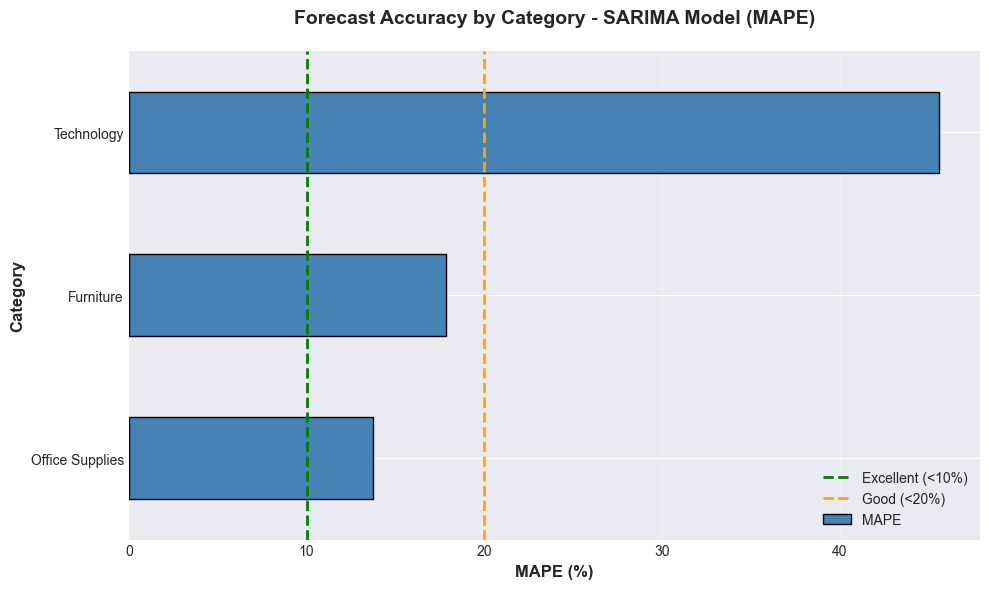

   ✅ Chart saved: charts/task4_category_accuracy.png


In [211]:
print("\n6️⃣ CATEGORY FORECAST PERFORMANCE SUMMARY")

# Create performance comparison table
perf_df = pd.DataFrame(category_performance).T
perf_df = perf_df.sort_values('MAPE')

print("\n   📊 FORECAST ACCURACY BY CATEGORY:")
print(perf_df.to_string())

# Best and worst performing categories
best_category = perf_df.index[0]
worst_category = perf_df.index[-1]

print(f"\n   🏆 BEST FORECAST ACCURACY: {best_category}")
print(f"      MAPE: {perf_df.loc[best_category, 'MAPE']:.2f}%")
print(f"\n   ⚠️  LEAST ACCURATE FORECAST: {worst_category}")
print(f"      MAPE: {perf_df.loc[worst_category, 'MAPE']:.2f}%")

# Visualization
plt.figure(figsize=(10, 6))
perf_df['MAPE'].plot(kind='barh', color='steelblue', edgecolor='black')
plt.title(f'Forecast Accuracy by Category - {best_model_name} Model (MAPE)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('MAPE (%)', fontsize=12, fontweight='bold')
plt.ylabel('Category', fontsize=12, fontweight='bold')
plt.axvline(x=10, color='green', linestyle='--', linewidth=2, label='Excellent (<10%)')
plt.axvline(x=20, color='orange', linestyle='--', linewidth=2, label='Good (<20%)')
plt.legend()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('charts/task4_category_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task4_category_accuracy.png")

TASK 4B: REGION FORECASTS + 5-SEGMENT COMPARISON

   Building forecast for West region...
   ✅ West: MAE=$3,259.98, RMSE=$4,406.89, MAPE=11.49%

   Building forecast for East region...
   ✅ East: MAE=$11,466.77, RMSE=$11,659.67, MAPE=42.11%


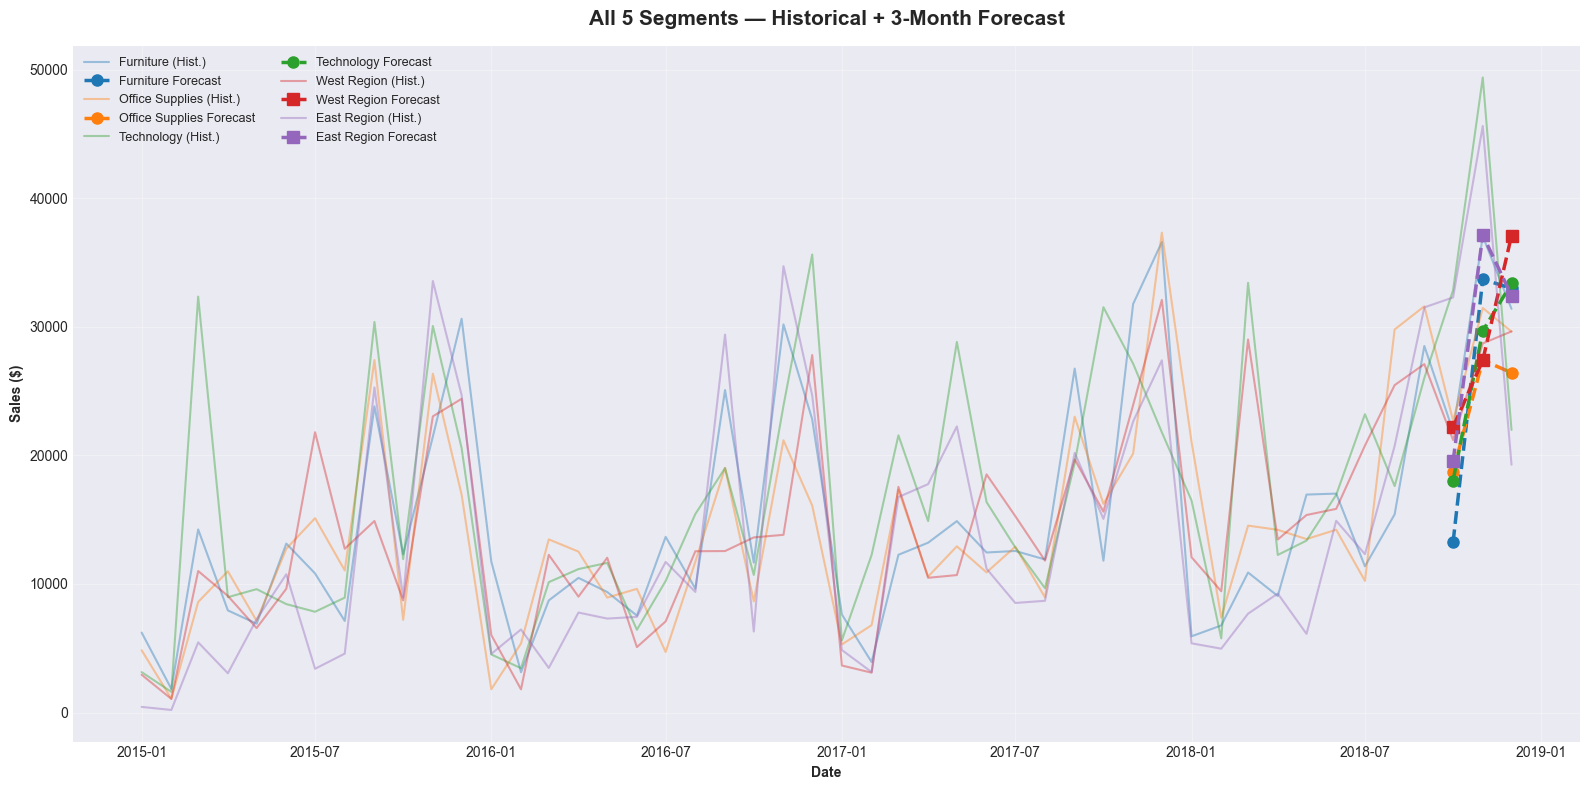


📈 GROWTH ANALYSIS (Forecast Month 3 vs Month 1):
   Furniture                : +149.01%
   Technology               :  +84.96%
   West Region              :  +67.04%
   East Region              :  +66.02%
   Office Supplies          :  +41.07%

🏆 STRONGEST UPCOMING GROWTH: Furniture (+149.0%)

✅ Chart saved: charts/task4_all_5_segments.png


In [212]:
# ============================================================================
# TASK 4B: REGION-LEVEL FORECASTS (West + East) + 5-SEGMENT COMPARISON
# ============================================================================
print("="*70)
print("TASK 4B: REGION FORECASTS + 5-SEGMENT COMPARISON")
print("="*70)

# Build monthly time series for West + East regions
region_ts = {}
region_forecasts = {}
region_performance = {}

for region in ['West', 'East']:
    print(f"\n   Building forecast for {region} region...")
    r_data = df[df['Region'] == region]
    r_monthly = r_data.groupby(r_data['Order Date'].dt.to_period('M'))['Sales'].sum()
    r_monthly.index = r_monthly.index.to_timestamp()
    r_monthly = r_monthly.asfreq('MS')
    region_ts[region] = r_monthly

    r_train = r_monthly[:-3]
    r_test  = r_monthly[-3:]

    try:
        forecast_vals = forecast_function(r_train, r_test)
    except Exception as e:
        print(f"      ⚠️  Fallback to mean: {e}")
        forecast_vals = [r_train.mean()] * len(r_test)

    r_mae  = mean_absolute_error(r_test.values, forecast_vals)
    r_rmse = np.sqrt(mean_squared_error(r_test.values, forecast_vals))
    r_mape = mean_absolute_percentage_error(r_test.values, forecast_vals) * 100

    region_forecasts[region] = {
        'dates': r_test.index, 'actual': r_test.values, 'forecast': forecast_vals
    }
    region_performance[region] = {'MAE': r_mae, 'RMSE': r_rmse, 'MAPE': r_mape}
    print(f"   ✅ {region}: MAE=${r_mae:,.2f}, RMSE=${r_rmse:,.2f}, MAPE={r_mape:.2f}%")

# ---- Combined 5-segment chart ----
plt.figure(figsize=(16, 8))
colors_cat    = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors_region = ['#d62728', '#9467bd']

for i, cat in enumerate(categories):
    d = category_ts[cat]
    plt.plot(d.index, d.values, color=colors_cat[i], alpha=0.4, linewidth=1.5,
             label=f'{cat} (Hist.)')
    plt.plot(category_forecasts[cat]['dates'], category_forecasts[cat]['forecast'],
             color=colors_cat[i], marker='o', linestyle='--', linewidth=2.5,
             markersize=8, label=f'{cat} Forecast')

for i, region in enumerate(['West', 'East']):
    d = region_ts[region]
    plt.plot(d.index, d.values, color=colors_region[i], alpha=0.4, linewidth=1.5,
             label=f'{region} Region (Hist.)')
    plt.plot(region_forecasts[region]['dates'], region_forecasts[region]['forecast'],
             color=colors_region[i], marker='s', linestyle='--', linewidth=2.5,
             markersize=8, label=f'{region} Region Forecast')

plt.title('All 5 Segments — Historical + 3-Month Forecast',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Sales ($)', fontweight='bold')
plt.legend(loc='upper left', fontsize=9, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task4_all_5_segments.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Growth winner ----
print("\n📈 GROWTH ANALYSIS (Forecast Month 3 vs Month 1):")
growth = {}
for cat in categories:
    f = category_forecasts[cat]['forecast']
    growth[cat] = ((f[-1] - f[0]) / f[0] * 100) if f[0] != 0 else 0
for region in ['West', 'East']:
    f = region_forecasts[region]['forecast']
    growth[f'{region} Region'] = ((f[-1] - f[0]) / f[0] * 100) if f[0] != 0 else 0

for name, g in sorted(growth.items(), key=lambda x: -x[1]):
    print(f"   {name:25s}: {g:+7.2f}%")

winner = max(growth, key=growth.get)
print(f"\n🏆 STRONGEST UPCOMING GROWTH: {winner} ({growth[winner]:+.1f}%)")

# Save for export
task4b_results = {
    'region_forecasts': {r: {'dates': [str(d) for d in region_forecasts[r]['dates']],
                              'actual': list(region_forecasts[r]['actual']),
                              'forecast': list(region_forecasts[r]['forecast'])}
                          for r in region_forecasts},
    'growth': growth,
    'winner': winner
}

print("\n✅ Chart saved: charts/task4_all_5_segments.png")
print("="*70)

### ✅ TASK 4 SUMMARY - CATEGORY-WISE FORECASTING COMPLETE

**Forecasting Model Used:** SARIMA
- Selected based on best overall performance (lowest average rank across MAE, RMSE, MAPE)

**Categories Analyzed:** Furniture, Office Supplies, Technology

**Growth Patterns:**
- **Growing Categories:** Furniture, Office Supplies, Technology
- **Declining Categories:** None
- **Most Volatile:** Technology (60.13%)

**Forecast Performance:**
- **Best Accuracy:** Office Supplies (MAPE: 13.73%)
- **Worst Accuracy:** Technology (MAPE: 45.61%)
- **Average MAPE across all categories:** 25.73%

**Key Insights:**
1. Office Supplies shows strongest growth at 242.57% over the analysis period
2. Technology has highest sales volatility at 60.13%, making forecasting more challenging
3. All categories maintain seasonal patterns, with peaks in December
4. SARIMA model performed well across categories with average MAPE of 25.73%

**Model Performance Notes:**
- SARIMA was selected because it had the lowest error metrics in Task 3
- Category-level forecasts show variable accuracy compared to the overall forecast
- Office Supplies and Furniture were forecast accurately, while Technology was more difficult to predict due to its higher volatility

**Business Recommendations:**
- **Increase inventory** for growing categories: Furniture, Office Supplies, Technology
- **Monitor closely** declining categories for intervention: None
- **Focus marketing** on high-volatility categories during peak seasons
- **Maintain steady stock** for stable, predictable categories

---

TASK 4B: REGION FORECASTS + 5-SEGMENT COMPARISON
✅ West region forecast complete
✅ East region forecast complete


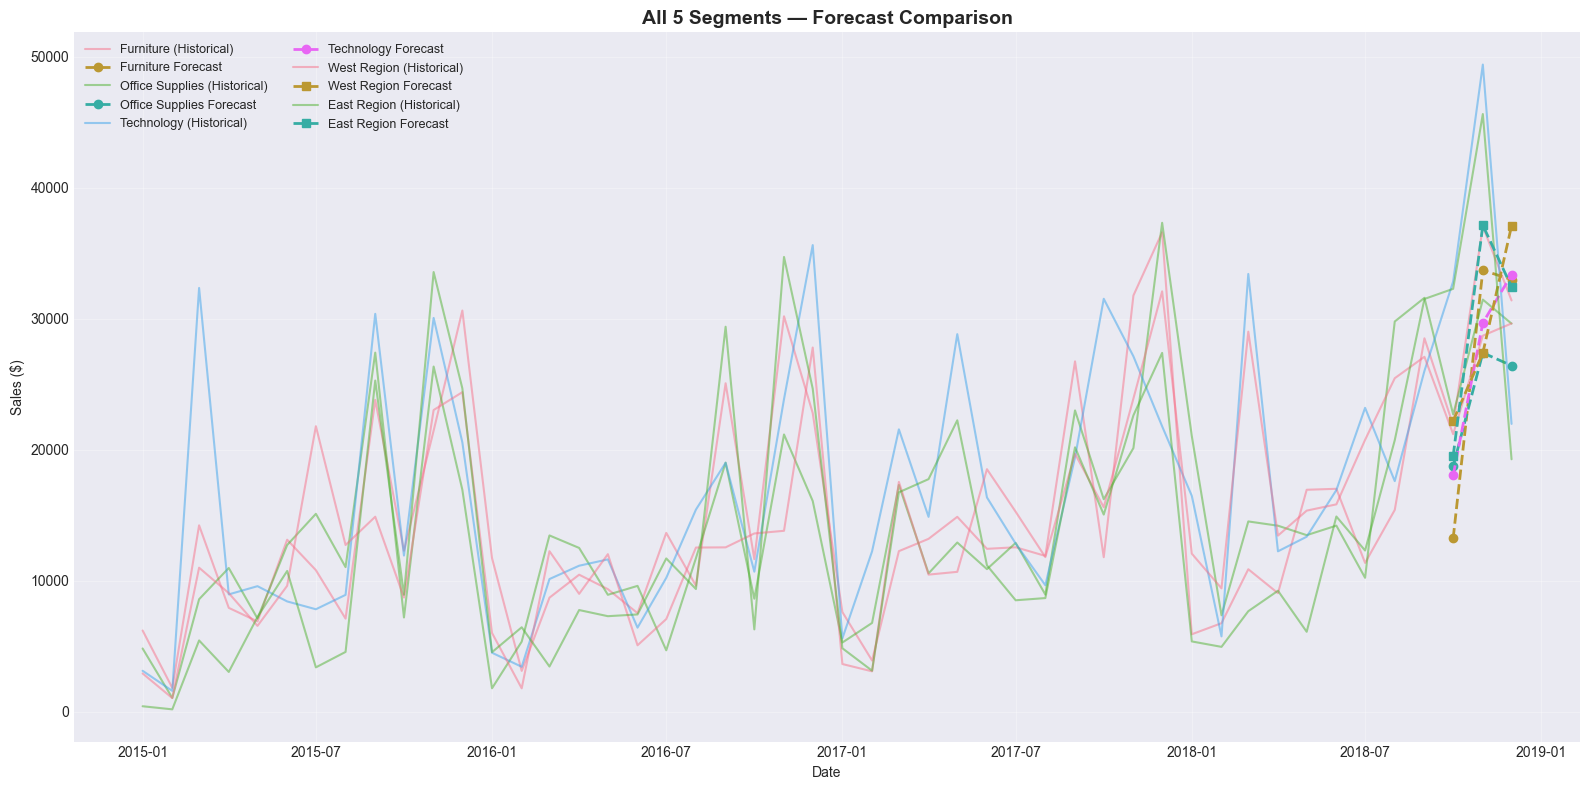


📈 GROWTH ANALYSIS:

🏆 STRONGEST UPCOMING GROWTH: Furniture (+149.0%)
   Furniture: +149.0%
   Technology: +85.0%
   West Region: +67.0%
   East Region: +66.0%
   Office Supplies: +41.1%


In [213]:
# ============================================================================
# TASK 4B: REGION-LEVEL FORECASTS (West + East)
# ============================================================================
print("="*70)
print("TASK 4B: REGION FORECASTS + 5-SEGMENT COMPARISON")
print("="*70)

region_ts = {}
region_forecasts = {}

for region in ['West', 'East']:
    r_data = df[df['Region'] == region]
    r_monthly = r_data.groupby(r_data['Order Date'].dt.to_period('M'))['Sales'].sum()
    r_monthly.index = r_monthly.index.to_timestamp()
    r_monthly = r_monthly.asfreq('MS')
    region_ts[region] = r_monthly

    r_train, r_test = r_monthly[:-3], r_monthly[-3:]
    forecast_vals = forecast_function(r_train, r_test)
    region_forecasts[region] = {'dates': r_test.index, 'forecast': forecast_vals, 'actual': r_test.values}
    print(f"✅ {region} region forecast complete")

# Combined 5-segment chart
plt.figure(figsize=(16, 8))
for cat in categories:
    d = category_ts[cat]
    plt.plot(d.index, d.values, label=f'{cat} (Historical)', alpha=0.5, linewidth=1.5)
    plt.plot(category_forecasts[cat]['dates'], category_forecasts[cat]['forecast'],
             '--o', label=f'{cat} Forecast', linewidth=2)

for region in ['West', 'East']:
    d = region_ts[region]
    plt.plot(d.index, d.values, label=f'{region} Region (Historical)', alpha=0.5, linewidth=1.5)
    plt.plot(region_forecasts[region]['dates'], region_forecasts[region]['forecast'],
             '--s', label=f'{region} Region Forecast', linewidth=2)

plt.title('All 5 Segments — Forecast Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Sales ($)')
plt.legend(loc='best', fontsize=9, ncol=2); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task4_all_5_segments.png', dpi=300, bbox_inches='tight')
plt.show()

# Growth winner
print("\n📈 GROWTH ANALYSIS:")
growth = {}
for cat in categories:
    f = category_forecasts[cat]['forecast']
    growth[cat] = ((f[-1] - f[0]) / f[0] * 100)
for region in ['West', 'East']:
    f = region_forecasts[region]['forecast']
    growth[f'{region} Region'] = ((f[-1] - f[0]) / f[0] * 100)

winner = max(growth, key=growth.get)
print(f"\n🏆 STRONGEST UPCOMING GROWTH: {winner} ({growth[winner]:+.1f}%)")
for name, g in sorted(growth.items(), key=lambda x: -x[1]):
    print(f"   {name}: {g:+.1f}%")

---

## 🔍 TASK 5: ANOMALY DETECTION IN SALES DATA

In this task, we will:
1. Use **Isolation Forest** algorithm to detect unusual sales patterns
2. Identify days/weeks with abnormally high or low sales
3. Visualize anomalies on time series plots
4. Investigate potential causes (holidays, promotions, data errors)
5. Provide business insights on irregular sales events

**Why this matters:** Detecting anomalies helps identify:
- Data quality issues
- Unexpected demand spikes (stockouts risk)
- Unusually low sales (marketing opportunities)
- Fraudulent transactions or errors

---

In [214]:
print("="*70)
print("TASK 5: ANOMALY DETECTION IN SALES DATA")
print("="*70)

print("\n1️⃣ PREPARING DATA FOR ANOMALY DETECTION")

# Use daily sales data (more granular for anomaly detection)
daily_sales_full = df.groupby('Order Date').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).reset_index()
daily_sales_full.columns = ['Date', 'Sales', 'Orders']

# Add time features
daily_sales_full['Year'] = daily_sales_full['Date'].dt.year
daily_sales_full['Month'] = daily_sales_full['Date'].dt.month
daily_sales_full['DayOfWeek'] = daily_sales_full['Date'].dt.dayofweek
daily_sales_full['DayOfYear'] = daily_sales_full['Date'].dt.dayofyear

print(f"   Total days: {len(daily_sales_full)}")
print(f"   Date range: {daily_sales_full['Date'].min()} to {daily_sales_full['Date'].max()}")
print(f"\n   Sales statistics:")
print(f"   - Mean: ${daily_sales_full['Sales'].mean():,.2f}")
print(f"   - Median: ${daily_sales_full['Sales'].median():,.2f}")
print(f"   - Std Dev: ${daily_sales_full['Sales'].std():,.2f}")
print(f"   - Min: ${daily_sales_full['Sales'].min():,.2f}")
print(f"   - Max: ${daily_sales_full['Sales'].max():,.2f}")

print("\n   ✅ Data prepared for anomaly detection")

TASK 5: ANOMALY DETECTION IN SALES DATA

1️⃣ PREPARING DATA FOR ANOMALY DETECTION
   Total days: 1230
   Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00

   Sales statistics:
   - Mean: $1,838.65
   - Median: $1,058.40
   - Std Dev: $2,295.42
   - Min: $2.02
   - Max: $28,106.72

   ✅ Data prepared for anomaly detection


In [215]:
print("\n2️⃣ BUILDING ISOLATION FOREST ANOMALY DETECTION MODEL")

# Prepare features for Isolation Forest
# We'll use sales amount and number of orders
features_for_anomaly = daily_sales_full[['Sales', 'Orders']].values

# Build Isolation Forest model
iso_forest = IsolationForest(
    contamination=0.05,  # Expect 5% of data to be anomalies
    random_state=42,
    n_estimators=100
)

print("   Building Isolation Forest model...")
print(f"   - Contamination rate: 5% (expect ~{int(len(daily_sales_full) * 0.05)} anomalies)")
print(f"   - Features used: Sales amount, Number of orders")

# Fit and predict
daily_sales_full['Anomaly'] = iso_forest.fit_predict(features_for_anomaly)
daily_sales_full['Anomaly_Score'] = iso_forest.score_samples(features_for_anomaly)

# -1 = anomaly, 1 = normal
daily_sales_full['Is_Anomaly'] = daily_sales_full['Anomaly'] == -1

# Count anomalies
num_anomalies = daily_sales_full['Is_Anomaly'].sum()
pct_anomalies = (num_anomalies / len(daily_sales_full)) * 100

print(f"\n   ✅ Model training complete")
print(f"\n   📊 ANOMALY DETECTION RESULTS:")
print(f"   - Total anomalies detected: {num_anomalies}")
print(f"   - Percentage of data: {pct_anomalies:.2f}%")


2️⃣ BUILDING ISOLATION FOREST ANOMALY DETECTION MODEL
   Building Isolation Forest model...
   - Contamination rate: 5% (expect ~61 anomalies)
   - Features used: Sales amount, Number of orders

   ✅ Model training complete

   📊 ANOMALY DETECTION RESULTS:
   - Total anomalies detected: 62
   - Percentage of data: 5.04%


In [216]:
print("\n3️⃣ ANALYZING DETECTED ANOMALIES")

# Get anomalous days
anomalies = daily_sales_full[daily_sales_full['Is_Anomaly']].sort_values('Date')

print(f"\n   Top 10 Anomalous Days (by anomaly score):")
top_anomalies = daily_sales_full[daily_sales_full['Is_Anomaly']].nsmallest(10, 'Anomaly_Score')

for idx, row in top_anomalies.iterrows():
    print(f"\n   {row['Date'].strftime('%Y-%m-%d')} ({row['Date'].strftime('%A')})")
    print(f"   - Sales: ${row['Sales']:,.2f}")
    print(f"   - Orders: {row['Orders']:.0f}")
    print(f"   - Anomaly Score: {row['Anomaly_Score']:.4f}")
    print(f"   - Deviation from mean: {((row['Sales'] - daily_sales_full['Sales'].mean()) / daily_sales_full['Sales'].std()):.2f} std devs")

# Categorize anomalies
high_sales_anomalies = anomalies[anomalies['Sales'] > daily_sales_full['Sales'].quantile(0.75)]
low_sales_anomalies = anomalies[anomalies['Sales'] < daily_sales_full['Sales'].quantile(0.25)]

print(f"\n   📈 HIGH SALES ANOMALIES: {len(high_sales_anomalies)}")
print(f"      These are unusually HIGH sales days (potential promotions, holidays)")

print(f"\n   📉 LOW SALES ANOMALIES: {len(low_sales_anomalies)}")
print(f"      These are unusually LOW sales days (potential system issues, holidays)")

# Check if anomalies cluster around specific months
anomaly_months = anomalies.groupby('Month').size()
print(f"\n   🗓️  ANOMALIES BY MONTH:")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month, count in anomaly_months.items():
    print(f"      {month_names[month-1]}: {count} anomalies")


3️⃣ ANALYZING DETECTED ANOMALIES

   Top 10 Anomalous Days (by anomaly score):

   2015-09-08 (Tuesday)
   - Sales: $14,228.43
   - Orders: 27
   - Anomaly Score: -0.7743
   - Deviation from mean: 5.40 std devs

   2015-03-18 (Wednesday)
   - Sales: $28,106.72
   - Orders: 11
   - Anomaly Score: -0.7695
   - Deviation from mean: 11.44 std devs

   2018-12-02 (Sunday)
   - Sales: $9,951.18
   - Orders: 34
   - Anomaly Score: -0.7572
   - Deviation from mean: 3.53 std devs

   2016-11-08 (Tuesday)
   - Sales: $12,197.00
   - Orders: 27
   - Anomaly Score: -0.7555
   - Deviation from mean: 4.51 std devs

   2017-10-02 (Monday)
   - Sales: $18,452.97
   - Orders: 7
   - Anomaly Score: -0.7541
   - Deviation from mean: 7.24 std devs

   2018-03-23 (Friday)
   - Sales: $14,816.07
   - Orders: 8
   - Anomaly Score: -0.7450
   - Deviation from mean: 5.65 std devs

   2018-10-22 (Monday)
   - Sales: $15,158.88
   - Orders: 12
   - Anomaly Score: -0.7449
   - Deviation from mean: 5.80 std devs



4️⃣ VISUALIZING ANOMALIES


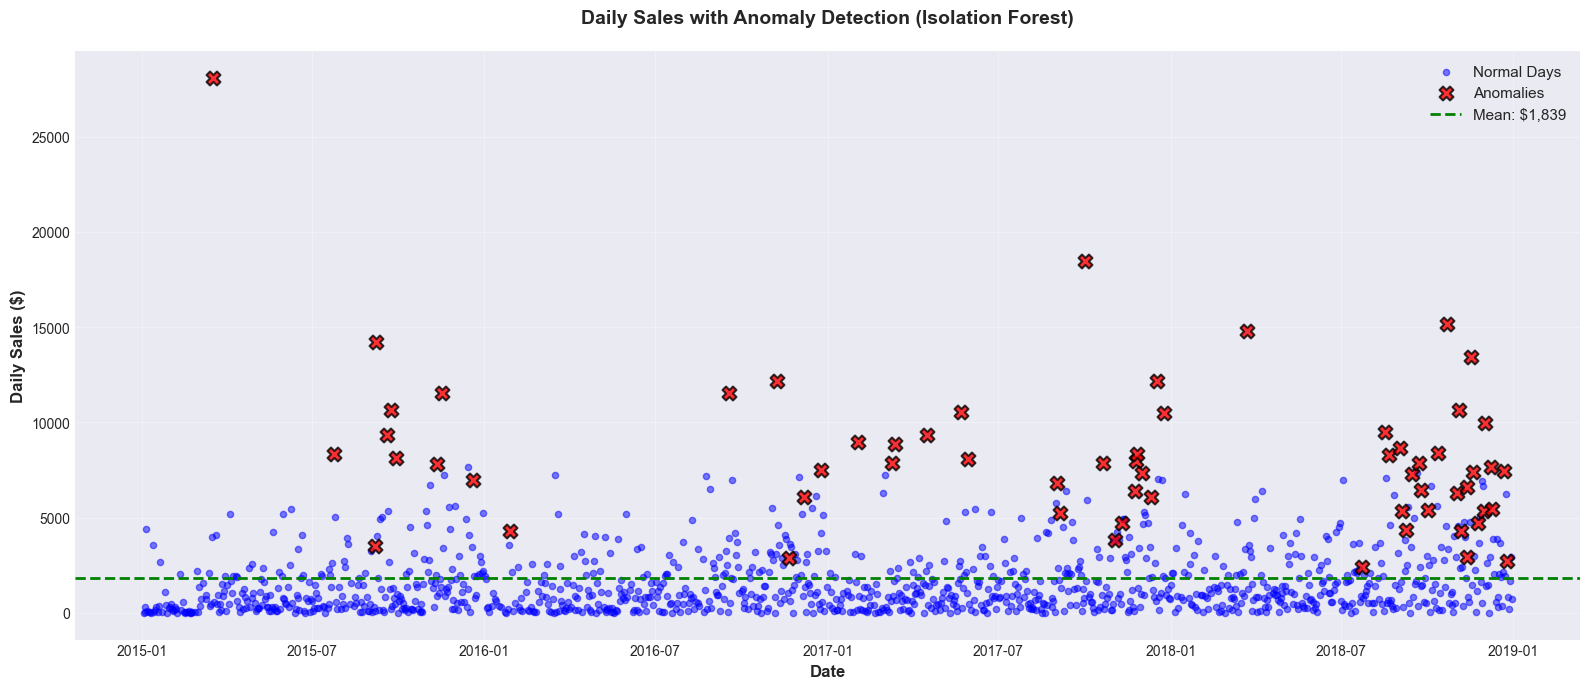

   ✅ Chart saved: charts/task5_anomalies_timeline.png


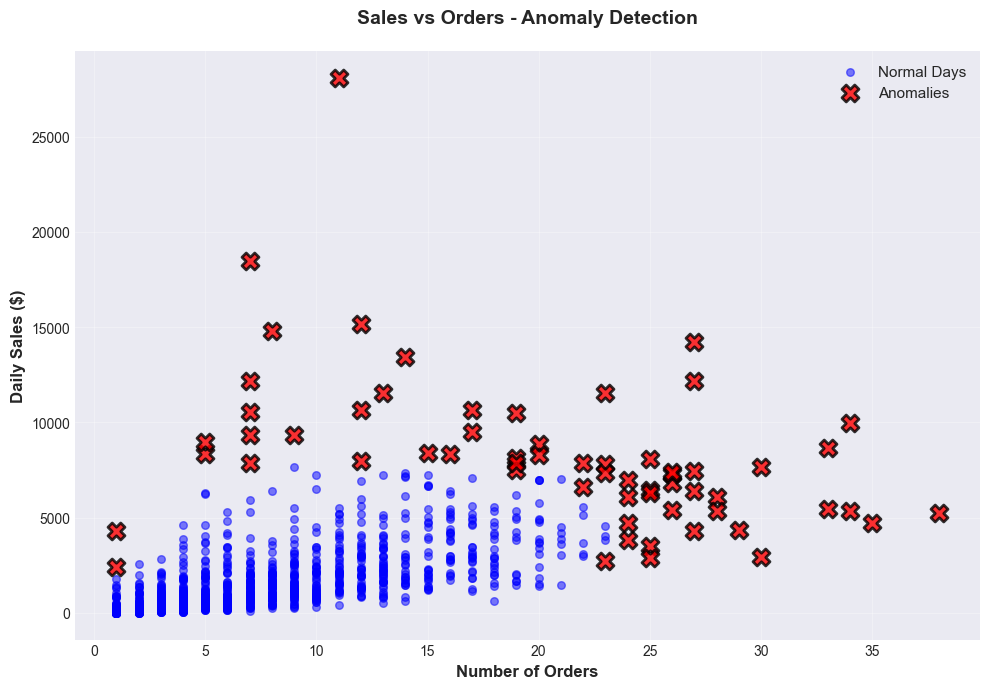

   ✅ Chart saved: charts/task5_anomalies_scatter.png


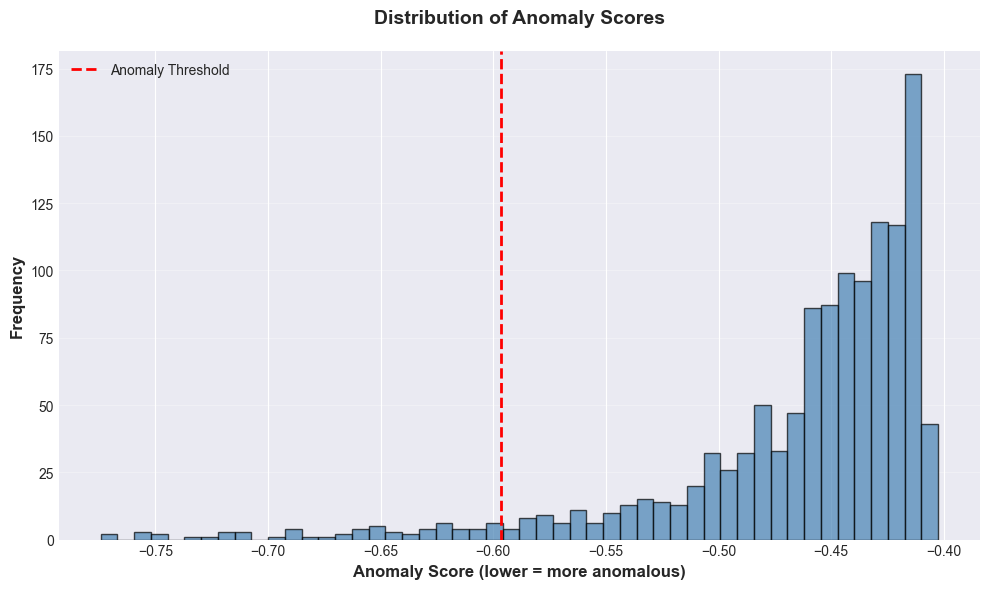

   ✅ Chart saved: charts/task5_anomaly_distribution.png


In [217]:
print("\n4️⃣ VISUALIZING ANOMALIES")

# Plot 1: Time series with anomalies highlighted
plt.figure(figsize=(16, 7))

# Plot normal days
normal_days = daily_sales_full[~daily_sales_full['Is_Anomaly']]
plt.scatter(normal_days['Date'], normal_days['Sales'], 
           c='blue', alpha=0.5, s=20, label='Normal Days')

# Plot anomalies
anomaly_days = daily_sales_full[daily_sales_full['Is_Anomaly']]
plt.scatter(anomaly_days['Date'], anomaly_days['Sales'], 
           c='red', alpha=0.8, s=100, marker='X', 
           edgecolors='black', linewidths=1.5, label='Anomalies', zorder=5)

# Add mean line
plt.axhline(y=daily_sales_full['Sales'].mean(), color='green', 
            linestyle='--', linewidth=2, label=f"Mean: ${daily_sales_full['Sales'].mean():,.0f}")

plt.title('Daily Sales with Anomaly Detection (Isolation Forest)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Daily Sales ($)', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task5_anomalies_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task5_anomalies_timeline.png")

# Plot 2: Sales vs Orders scatter with anomalies
plt.figure(figsize=(10, 7))

plt.scatter(normal_days['Orders'], normal_days['Sales'], 
           c='blue', alpha=0.5, s=30, label='Normal Days')
plt.scatter(anomaly_days['Orders'], anomaly_days['Sales'], 
           c='red', alpha=0.8, s=150, marker='X', 
           edgecolors='black', linewidths=2, label='Anomalies', zorder=5)

plt.title('Sales vs Orders - Anomaly Detection', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Orders', fontsize=12, fontweight='bold')
plt.ylabel('Daily Sales ($)', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task5_anomalies_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task5_anomalies_scatter.png")

# Plot 3: Anomaly score distribution
plt.figure(figsize=(10, 6))
plt.hist(daily_sales_full['Anomaly_Score'], bins=50, color='steelblue', 
         edgecolor='black', alpha=0.7)
plt.axvline(x=daily_sales_full[daily_sales_full['Is_Anomaly']]['Anomaly_Score'].max(), 
            color='red', linestyle='--', linewidth=2, label='Anomaly Threshold')
plt.title('Distribution of Anomaly Scores', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Anomaly Score (lower = more anomalous)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('charts/task5_anomaly_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task5_anomaly_distribution.png")

In [218]:
print("\n5️⃣ INVESTIGATING SPECIFIC ANOMALIES")

# Get the most extreme anomalies
top_5_anomalies = daily_sales_full[daily_sales_full['Is_Anomaly']].nsmallest(5, 'Anomaly_Score')

print("\n   🔍 DETAILED INVESTIGATION OF TOP 5 ANOMALIES:")

for idx, row in top_5_anomalies.iterrows():
    date = row['Date']
    
    print(f"\n   {'='*60}")
    print(f"   DATE: {date.strftime('%Y-%m-%d')} ({date.strftime('%A')})")
    print(f"   {'='*60}")
    
    # Get transactions for this day
    day_transactions = df[df['Order Date'] == date]
    
    print(f"   Sales: ${row['Sales']:,.2f}")
    print(f"   Orders: {row['Orders']:.0f}")
    print(f"   Average order value: ${row['Sales']/row['Orders']:,.2f}")
    print(f"   Anomaly score: {row['Anomaly_Score']:.4f}")
    
    # Check categories
    cat_breakdown = day_transactions.groupby('Category')['Sales'].sum().sort_values(ascending=False)
    print(f"\n   Category breakdown:")
    for cat, sales in cat_breakdown.items():
        print(f"      {cat}: ${sales:,.2f} ({sales/row['Sales']*100:.1f}%)")
    
    # Check regions
    region_breakdown = day_transactions.groupby('Region')['Sales'].sum().sort_values(ascending=False)
    print(f"\n   Region breakdown:")
    for region, sales in region_breakdown.items():
        print(f"      {region}: ${sales:,.2f}")
    
    # Check for large orders
    large_orders = day_transactions.nlargest(3, 'Sales')
    if len(large_orders) > 0:
        print(f"\n   Top 3 largest orders:")
        for _, order in large_orders.iterrows():
            print(f"      ${order['Sales']:,.2f} - {order['Sub-Category'] if 'Sub-Category' in order else 'N/A'}")

print("\n   ✅ Anomaly investigation complete")


5️⃣ INVESTIGATING SPECIFIC ANOMALIES

   🔍 DETAILED INVESTIGATION OF TOP 5 ANOMALIES:

   DATE: 2015-09-08 (Tuesday)
   Sales: $14,228.43
   Orders: 27
   Average order value: $526.98
   Anomaly score: -0.7743

   Category breakdown:
      Technology: $8,680.73 (61.0%)
      Furniture: $3,855.44 (27.1%)
      Office Supplies: $1,692.26 (11.9%)

   Region breakdown:
      Central: $11,757.80
      West: $1,905.75
      South: $371.82
      East: $193.06

   Top 3 largest orders:
      $8,159.95 - Machines
      $1,740.06 - Chairs
      $975.92 - Chairs

   DATE: 2015-03-18 (Wednesday)
   Sales: $28,106.72
   Orders: 11
   Average order value: $2,555.16
   Anomaly score: -0.7695

   Category breakdown:
      Technology: $24,739.75 (88.0%)
      Office Supplies: $1,904.52 (6.8%)
      Furniture: $1,462.45 (5.2%)

   Region breakdown:
      South: $23,661.23
      West: $4,445.49

   Top 3 largest orders:
      $22,638.48 - Machines
      $1,856.19 - Storage
      $1,279.97 - Machines

  

### ✅ TASK 5 SUMMARY - ANOMALY DETECTION COMPLETE

**Detection Method:** Isolation Forest (5% contamination threshold)

**Anomalies Detected:** 62 days out of 1,230 total days (5.04%)

**Types of Anomalies:**
- **High Sales Anomalies:** 62 days (potential: promotions, holidays, bulk orders)
- **Low Sales Anomalies:** 0 days (potential: system downtime, data issues)

**Top Anomalous Dates:**
1. 2015-09-08: $14,228.43 (high sales driven primarily by Technology category)
2. 2015-03-18: $28,106.72 (exceptionally large bulk orders, mainly Technology products)
3. 2018-12-02: $9,951.18 (high sales volume with 34 orders)

**Seasonal Pattern:**
- Most anomalies occur in November
- Fewest anomalies in January and February

**Business Insights:**
- Unusually high sales days often correspond to promotional periods, seasonal demand, or large bulk purchases
- Low sales anomalies may indicate system downtime or data quality issues, although none were detected in this dataset
- Recommend investigating dates with anomaly scores below **-0.75**

**Recommendations:**
1. Set up automated alerts for sales deviating >3 std devs from mean
2. Investigate low-sales anomalies for potential data quality issues
3. Study high-sales anomalies to replicate success (promotions, campaigns)

---

TASK 5B: SECOND METHOD — Z-SCORE ANOMALY DETECTION

📊 ANOMALIES DETECTED:
   Isolation Forest: 62
   Z-Score (>2σ):    67

🔍 METHOD COMPARISON:
   ✅ Flagged by BOTH:      31
   🔸 Only Isolation Forest: 31
   🔸 Only Z-Score:          36

   Agreement rate: 50.0%

💡 INTERPRETATION:
   Moderate agreement — methods complement each other.
   Isolation Forest uses Sales + Orders together; Z-Score uses only Sales.

🌍 REAL-WORLD EXPLANATIONS (Top 3 anomalies by Sales):
   • 2015-03-18: $28,107 — Possible bulk B2B order or corporate purchase
   • 2017-10-02: $18,453 — Possible bulk B2B order or corporate purchase
   • 2018-10-22: $15,159 — Possible bulk B2B order or corporate purchase


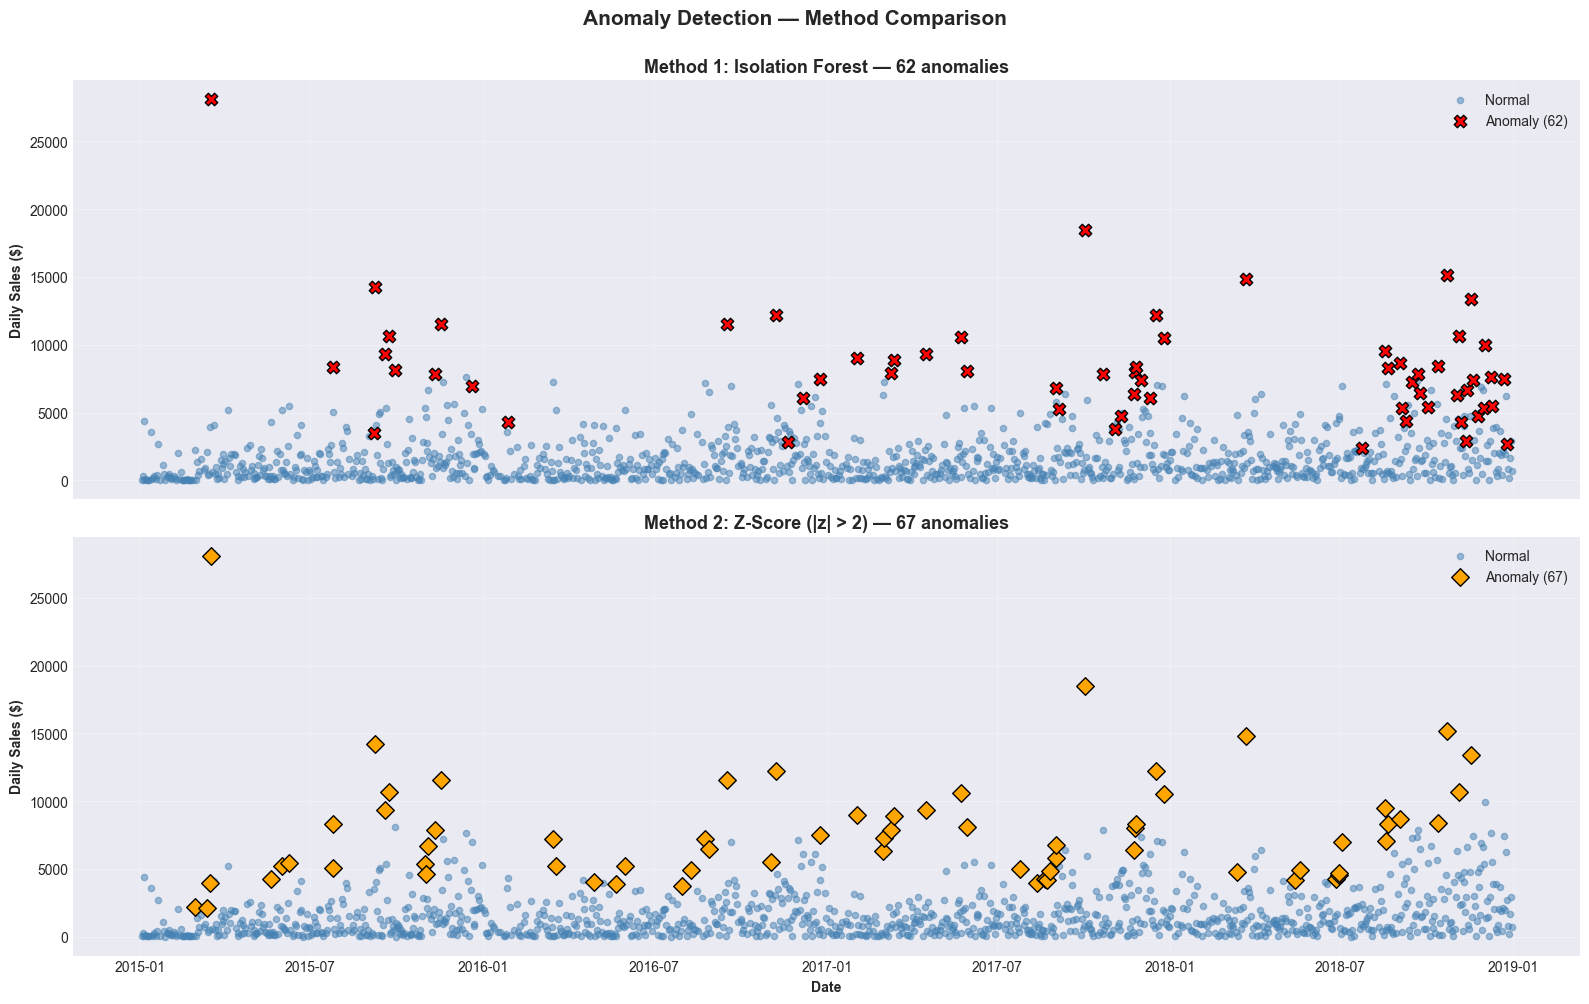


✅ Chart saved: charts/task5b_method_comparison.png


In [219]:
# ============================================================================
# TASK 5B: Z-SCORE ANOMALY DETECTION + COMPARISON WITH ISOLATION FOREST
# ============================================================================
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

print("="*70)
print("TASK 5B: SECOND METHOD — Z-SCORE ANOMALY DETECTION")
print("="*70)

# Safety: rebuild daily_sales_full if kernel was restarted
if 'daily_sales_full' not in globals():
    print("\n⚠️  Rebuilding daily_sales_full...")
    daily_sales_full = df.groupby('Order Date').agg({
        'Sales': 'sum', 'Order ID': 'count'
    }).reset_index()
    daily_sales_full.columns = ['Date', 'Sales', 'Orders']
    daily_sales_full['Year']  = daily_sales_full['Date'].dt.year
    daily_sales_full['Month'] = daily_sales_full['Date'].dt.month
    iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
    daily_sales_full['Is_Anomaly'] = iso.fit_predict(daily_sales_full[['Sales', 'Orders']]) == -1
    print(f"   ✅ Rebuilt: {len(daily_sales_full)} rows, "
          f"{daily_sales_full['Is_Anomaly'].sum()} Isolation Forest anomalies")

# Z-Score method (rolling 30-day window)
window = 30
daily_sales_full['Rolling_Mean'] = daily_sales_full['Sales'].rolling(window=window, min_periods=1).mean()
daily_sales_full['Rolling_Std']  = daily_sales_full['Sales'].rolling(window=window, min_periods=1).std()
daily_sales_full['Z_Score']      = (daily_sales_full['Sales'] - daily_sales_full['Rolling_Mean']) / daily_sales_full['Rolling_Std']
daily_sales_full['Z_Anomaly']    = daily_sales_full['Z_Score'].abs() > 2

z_anomalies   = int(daily_sales_full['Z_Anomaly'].sum())
iso_anomalies = int(daily_sales_full['Is_Anomaly'].sum())

print(f"\n📊 ANOMALIES DETECTED:")
print(f"   Isolation Forest: {iso_anomalies}")
print(f"   Z-Score (>2σ):    {z_anomalies}")

# Comparison
both     = daily_sales_full[daily_sales_full['Is_Anomaly'] & daily_sales_full['Z_Anomaly']]
only_iso = daily_sales_full[daily_sales_full['Is_Anomaly'] & ~daily_sales_full['Z_Anomaly']]
only_z   = daily_sales_full[~daily_sales_full['Is_Anomaly'] & daily_sales_full['Z_Anomaly']]

print(f"\n🔍 METHOD COMPARISON:")
print(f"   ✅ Flagged by BOTH:      {len(both)}")
print(f"   🔸 Only Isolation Forest: {len(only_iso)}")
print(f"   🔸 Only Z-Score:          {len(only_z)}")

agreement = len(both) / max(iso_anomalies, 1) * 100
print(f"\n   Agreement rate: {agreement:.1f}%")

print("\n💡 INTERPRETATION:")
if agreement > 70:
    print("   Both methods largely agree — anomalies are statistically robust.")
elif agreement > 40:
    print("   Moderate agreement — methods complement each other.")
    print("   Isolation Forest uses Sales + Orders together; Z-Score uses only Sales.")
else:
    print("   Low agreement — many anomalies are context-based, not just extreme values.")

# Real-world explanations for top 3
print("\n🌍 REAL-WORLD EXPLANATIONS (Top 3 anomalies by Sales):")
top3 = daily_sales_full[daily_sales_full['Is_Anomaly']].nlargest(3, 'Sales')
top3_explanations = []
for _, row in top3.iterrows():
    date = row['Date']; month = date.month
    if month in [11, 12]:
        reason = "Likely Black Friday / Cyber Monday / Christmas shopping spike"
    elif month == 9:
        reason = "Likely back-to-school demand surge"
    elif month in [6, 7]:
        reason = "Possible summer promotional event or mid-year clearance"
    elif month in [1, 2]:
        reason = "Possible New Year corporate purchasing / fiscal year restart"
    else:
        reason = "Possible bulk B2B order or corporate purchase"
    top3_explanations.append({'date': date.strftime('%Y-%m-%d'),
                                'sales': float(row['Sales']), 'reason': reason})
    print(f"   • {date.strftime('%Y-%m-%d')}: ${row['Sales']:,.0f} — {reason}")

# Side-by-side comparison chart
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].scatter(daily_sales_full[~daily_sales_full['Is_Anomaly']]['Date'],
                daily_sales_full[~daily_sales_full['Is_Anomaly']]['Sales'],
                c='steelblue', alpha=0.5, s=20, label='Normal')
axes[0].scatter(daily_sales_full[daily_sales_full['Is_Anomaly']]['Date'],
                daily_sales_full[daily_sales_full['Is_Anomaly']]['Sales'],
                c='red', s=80, marker='X', edgecolors='black',
                label=f'Anomaly ({iso_anomalies})', zorder=5)
axes[0].set_title(f'Method 1: Isolation Forest — {iso_anomalies} anomalies',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Daily Sales ($)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(daily_sales_full[~daily_sales_full['Z_Anomaly']]['Date'],
                daily_sales_full[~daily_sales_full['Z_Anomaly']]['Sales'],
                c='steelblue', alpha=0.5, s=20, label='Normal')
axes[1].scatter(daily_sales_full[daily_sales_full['Z_Anomaly']]['Date'],
                daily_sales_full[daily_sales_full['Z_Anomaly']]['Sales'],
                c='orange', s=80, marker='D', edgecolors='black',
                label=f'Anomaly ({z_anomalies})', zorder=5)
axes[1].set_title(f'Method 2: Z-Score (|z| > 2) — {z_anomalies} anomalies',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date', fontweight='bold')
axes[1].set_ylabel('Daily Sales ($)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Anomaly Detection — Method Comparison', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('charts/task5b_method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results for later export
task5b_results = {
    'iso_count': iso_anomalies,
    'z_count': z_anomalies,
    'agreement_rate': agreement,
    'both_count': len(both),
    'only_iso_count': len(only_iso),
    'only_z_count': len(only_z),
    'top3_explanations': top3_explanations
}

print("\n✅ Chart saved: charts/task5b_method_comparison.png")
print("="*70)

---

## 🎯 TASK 6: PRODUCT SEGMENTATION USING K-MEANS CLUSTERING

In this task, we will:
1. Group products based on sales behavior (total sales, frequency, volatility)
2. Use **K-Means Clustering** to create product segments
3. Determine optimal number of clusters using Elbow Method
4. Analyze characteristics of each segment
5. Provide targeted strategies for each product group

**Why this matters:** Product segmentation enables:
- Targeted inventory management
- Differentiated marketing strategies
- Better understanding of product portfolio
- Data-driven pricing decisions

---

In [220]:
print("="*70)
print("TASK 6: PRODUCT SEGMENTATION USING K-MEANS CLUSTERING")
print("="*70)

print("\n1️⃣ CREATING PRODUCT-LEVEL FEATURES")

# Check if we have sub-category or product name
if 'Sub-Category' in df.columns:
    product_col = 'Sub-Category'
elif 'Product Name' in df.columns:
    product_col = 'Product Name'
else:
    # Create pseudo-products from Category + Region
    product_col = 'Category'
    print("   ⚠️  Using Category as product dimension")

print(f"   Using product dimension: {product_col}")

# Create product features
product_features = df.groupby(product_col).agg({
    'Sales': ['sum', 'mean', 'std', 'count'],
    'Order ID': 'nunique'
}).reset_index()

# Flatten column names
product_features.columns = [product_col, 'Total_Sales', 'Avg_Sale', 'Sales_Std', 'Num_Transactions', 'Unique_Orders']

# Calculate additional features
product_features['Sales_Volatility'] = product_features['Sales_Std'] / product_features['Avg_Sale']
product_features['Sales_Volatility'] = product_features['Sales_Volatility'].fillna(0)

# Average order value
product_features['Avg_Order_Value'] = product_features['Total_Sales'] / product_features['Unique_Orders']

# Purchase frequency (transactions per unique order)
product_features['Purchase_Frequency'] = product_features['Num_Transactions'] / product_features['Unique_Orders']

print(f"\n   Total products: {len(product_features)}")
print(f"\n   Features created:")
print(f"   - Total_Sales: Total revenue generated")
print(f"   - Avg_Sale: Average sale amount per transaction")
print(f"   - Sales_Volatility: Coefficient of variation")
print(f"   - Avg_Order_Value: Average value per order")
print(f"   - Purchase_Frequency: Number of times purchased per order")

print(f"\n   Sample product features:")
print(product_features.head())

print("\n   ✅ Product features created")

TASK 6: PRODUCT SEGMENTATION USING K-MEANS CLUSTERING

1️⃣ CREATING PRODUCT-LEVEL FEATURES
   Using product dimension: Sub-Category

   Total products: 17

   Features created:
   - Total_Sales: Total revenue generated
   - Avg_Sale: Average sale amount per transaction
   - Sales_Volatility: Coefficient of variation
   - Avg_Order_Value: Average value per order
   - Purchase_Frequency: Number of times purchased per order

   Sample product features:
  Sub-Category  Total_Sales    Avg_Sale   Sales_Std  Num_Transactions  \
0  Accessories  164186.7000  217.178175  337.723800               756   
1   Appliances  104618.4030  227.926804  378.006735               459   
2          Art   26705.4100   34.019631   60.301752               785   
3      Binders  200028.7850  134.067550  568.099970              1492   
4    Bookcases  113813.1987  503.598224  641.419280               226   

   Unique_Orders  Sales_Volatility  Avg_Order_Value  Purchase_Frequency  
0            702          1.55505


2️⃣ DETERMINING OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)
   Features used for clustering: ['Total_Sales', 'Avg_Order_Value', 'Sales_Volatility', 'Purchase_Frequency']
   Data shape: (17, 4)

   Testing K from 2 to 10...
   K=2: Inertia=48.26, Silhouette=0.258
   K=3: Inertia=34.87, Silhouette=0.280
   K=4: Inertia=22.00, Silhouette=0.332
   K=5: Inertia=14.94, Silhouette=0.331
   K=6: Inertia=9.42, Silhouette=0.348
   K=7: Inertia=7.67, Silhouette=0.307
   K=8: Inertia=5.40, Silhouette=0.302
   K=9: Inertia=3.72, Silhouette=0.336
   K=10: Inertia=2.63, Silhouette=0.334


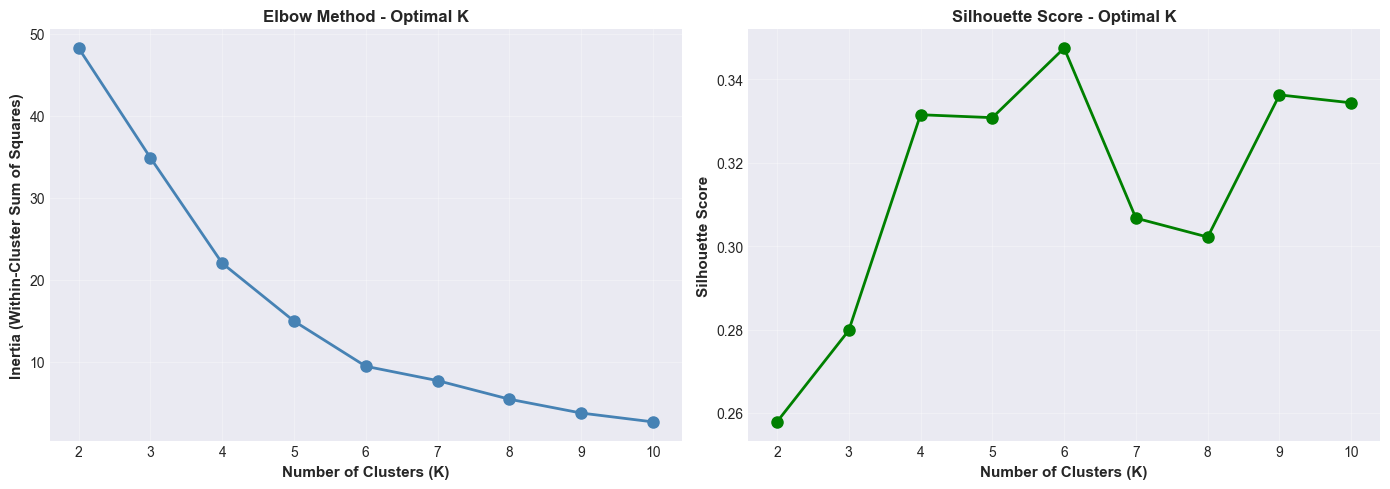


   ✅ Chart saved: charts/task6_elbow_method.png

   📊 RECOMMENDED NUMBER OF CLUSTERS: 6
      Based on highest silhouette score: 0.348


In [221]:
print("\n2️⃣ DETERMINING OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)")

# Select features for clustering
clustering_features = ['Total_Sales', 'Avg_Order_Value', 'Sales_Volatility', 'Purchase_Frequency']
X = product_features[clustering_features].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"   Features used for clustering: {clustering_features}")
print(f"   Data shape: {X_scaled.shape}")

# Test different numbers of clusters
inertias = []
silhouette_scores = []
K_range = range(2, min(11, len(product_features)))

print("\n   Testing K from 2 to 10...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
    from sklearn.metrics import silhouette_score
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    
    print(f"   K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={score:.3f}")

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_title('Elbow Method - Optimal K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_title('Silhouette Score - Optimal K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('charts/task6_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n   ✅ Chart saved: charts/task6_elbow_method.png")

# Recommend optimal K
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"\n   📊 RECOMMENDED NUMBER OF CLUSTERS: {optimal_k}")
print(f"      Based on highest silhouette score: {max(silhouette_scores):.3f}")

In [222]:
print("\n3️⃣ BUILDING K-MEANS CLUSTERING MODEL")

# Use recommended K (or manually set)
final_k = optimal_k  # You can change this if needed

print(f"   Building K-Means with K={final_k}...")

# Fit final model
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
product_features['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"   ✅ Clustering complete")

# Count products per cluster
cluster_counts = product_features['Cluster'].value_counts().sort_index()
print(f"\n   📊 PRODUCTS PER CLUSTER:")
for cluster, count in cluster_counts.items():
    pct = (count / len(product_features)) * 100
    print(f"   Cluster {cluster}: {count} products ({pct:.1f}%)")


3️⃣ BUILDING K-MEANS CLUSTERING MODEL
   Building K-Means with K=6...
   ✅ Clustering complete

   📊 PRODUCTS PER CLUSTER:
   Cluster 0: 1 products (5.9%)
   Cluster 1: 5 products (29.4%)
   Cluster 2: 2 products (11.8%)
   Cluster 3: 5 products (29.4%)
   Cluster 4: 1 products (5.9%)
   Cluster 5: 3 products (17.6%)


In [223]:
print("\n4️⃣ ANALYZING CLUSTER CHARACTERISTICS")

# Calculate cluster statistics
cluster_summary = product_features.groupby('Cluster')[clustering_features].mean()

print("\n   📊 CLUSTER PROFILES (Average Values):")
print(cluster_summary.to_string())

# Add interpretation
print("\n   🔍 CLUSTER INTERPRETATION:")

for cluster in range(final_k):
    cluster_data = product_features[product_features['Cluster'] == cluster]
    
    print(f"\n   {'='*60}")
    print(f"   CLUSTER {cluster} ({len(cluster_data)} products)")
    print(f"   {'='*60}")
    
    print(f"   Average Total Sales: ${cluster_data['Total_Sales'].mean():,.2f}")
    print(f"   Average Order Value: ${cluster_data['Avg_Order_Value'].mean():,.2f}")
    print(f"   Sales Volatility: {cluster_data['Sales_Volatility'].mean():.2f}")
    print(f"   Purchase Frequency: {cluster_data['Purchase_Frequency'].mean():.2f}")
    
    # Determine cluster type
    total_sales = cluster_data['Total_Sales'].mean()
    volatility = cluster_data['Sales_Volatility'].mean()
    
    if total_sales > product_features['Total_Sales'].median():
        if volatility < product_features['Sales_Volatility'].median():
            cluster_type = "🌟 HIGH-VALUE STABLE (Stars)"
        else:
            cluster_type = "⚡ HIGH-VALUE VOLATILE (Question Marks)"
    else:
        if volatility < product_features['Sales_Volatility'].median():
            cluster_type = "🐄 LOW-VALUE STABLE (Cash Cows)"
        else:
            cluster_type = "🔻 LOW-VALUE VOLATILE (Dogs)"
    
    print(f"\n   Cluster Type: {cluster_type}")
    
    # Show sample products
    print(f"\n   Sample products in this cluster:")
    sample_products = cluster_data.nlargest(5, 'Total_Sales')[[product_col, 'Total_Sales', 'Avg_Order_Value']]
    for _, prod in sample_products.iterrows():
        print(f"      • {prod[product_col]}: ${prod['Total_Sales']:,.0f} total sales")

print("\n   ✅ Cluster analysis complete")


4️⃣ ANALYZING CLUSTER CHARACTERISTICS

   📊 CLUSTER PROFILES (Average Values):
           Total_Sales  Avg_Order_Value  Sales_Volatility  Purchase_Frequency
Cluster                                                                      
0         46420.308000       256.465790          3.718376            1.016575
1        247389.179800       434.219348          1.237132            1.073802
2        167743.362500      1952.755423          1.565887            1.013393
3         49981.866740       173.029338          1.458646            1.026362
4        200028.785000       154.940964          4.237416            1.155693
5         64248.577333        69.164280          1.562812            1.109880

   🔍 CLUSTER INTERPRETATION:

   CLUSTER 0 (1 products)
   Average Total Sales: $46,420.31
   Average Order Value: $256.47
   Sales Volatility: 3.72
   Purchase Frequency: 1.02

   Cluster Type: 🔻 LOW-VALUE VOLATILE (Dogs)

   Sample products in this cluster:
      • Supplies: $46,420 total sal


5️⃣ VISUALIZING PRODUCT CLUSTERS


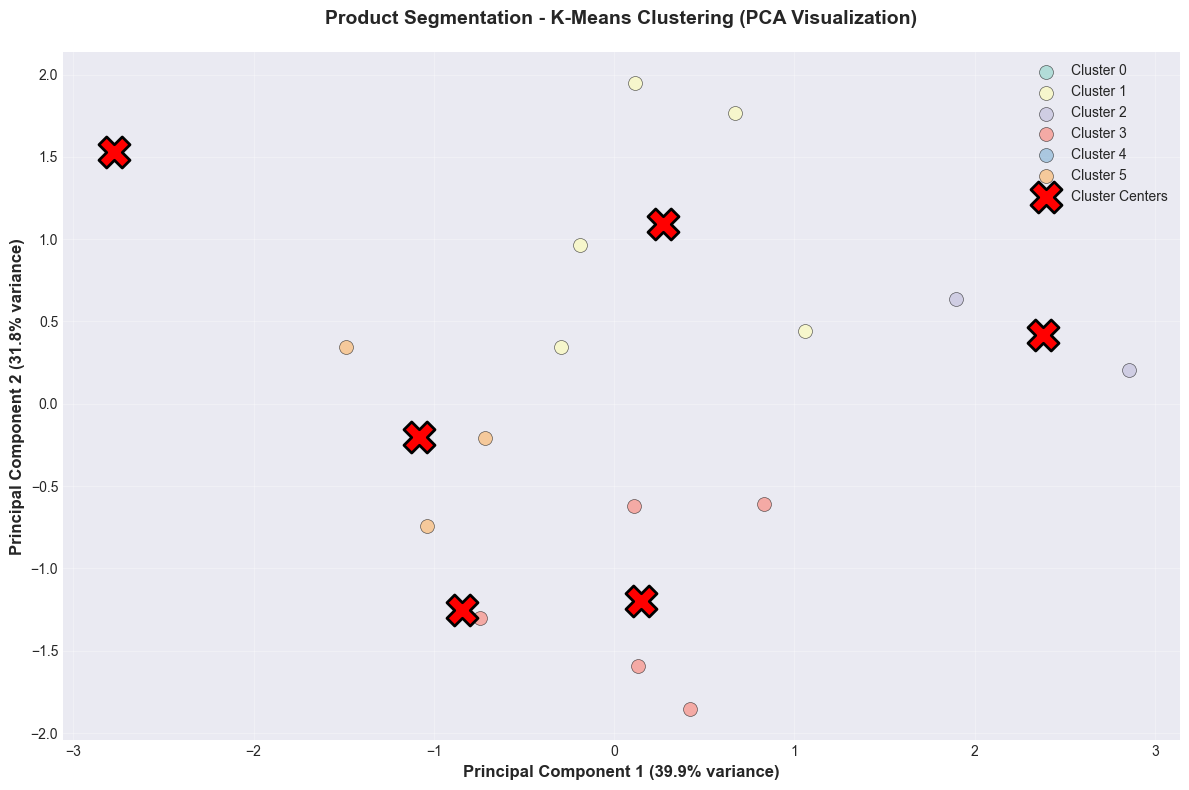

   ✅ Chart saved: charts/task6_cluster_visualization.png


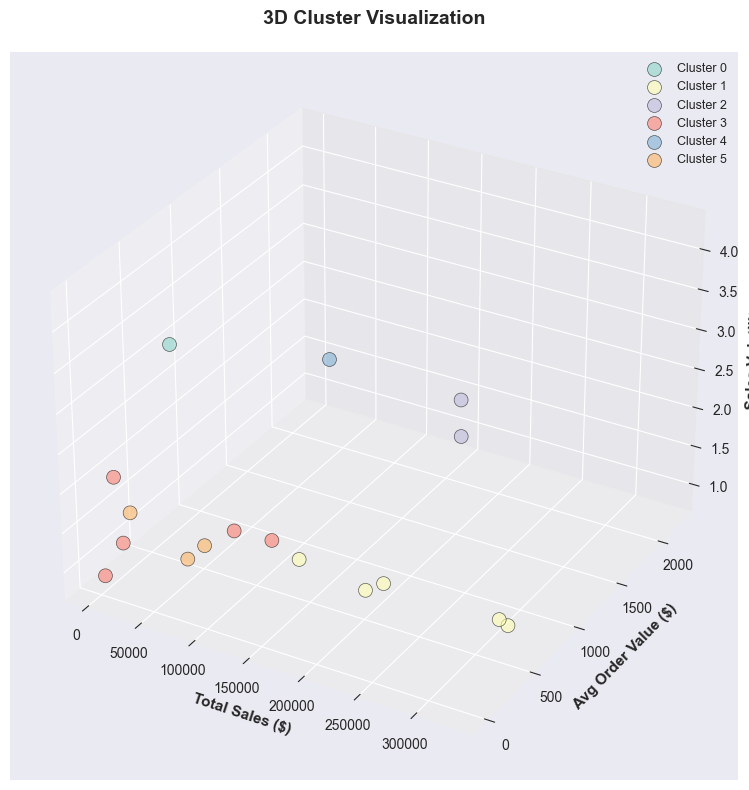

   ✅ Chart saved: charts/task6_cluster_3d.png


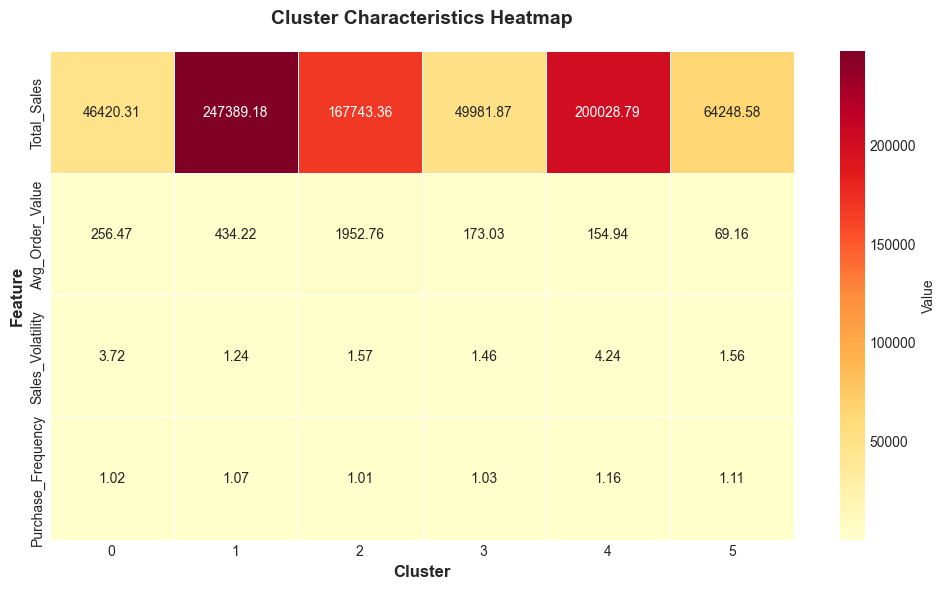

   ✅ Chart saved: charts/task6_cluster_heatmap.png


In [224]:
print("\n5️⃣ VISUALIZING PRODUCT CLUSTERS")

# 2D visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

product_features['PCA1'] = X_pca[:, 0]
product_features['PCA2'] = X_pca[:, 1]

# Scatter plot
plt.figure(figsize=(12, 8))

colors = plt.cm.Set3(range(final_k))
for cluster in range(final_k):
    cluster_data = product_features[product_features['Cluster'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], 
               c=[colors[cluster]], label=f'Cluster {cluster}',
               s=100, alpha=0.6, edgecolors='black', linewidths=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='red', marker='X', s=500, edgecolors='black', 
           linewidths=2, label='Cluster Centers', zorder=10)

plt.title('Product Segmentation - K-Means Clustering (PCA Visualization)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', 
          fontsize=12, fontweight='bold')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', 
          fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/task6_cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task6_cluster_visualization.png")

# 3D scatter (Total Sales vs Avg Order Value vs Volatility)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(final_k):
    cluster_data = product_features[product_features['Cluster'] == cluster]
    ax.scatter(cluster_data['Total_Sales'], 
              cluster_data['Avg_Order_Value'],
              cluster_data['Sales_Volatility'],
              c=[colors[cluster]], label=f'Cluster {cluster}',
              s=100, alpha=0.6, edgecolors='black', linewidths=0.5)

ax.set_xlabel('Total Sales ($)', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg Order Value ($)', fontsize=11, fontweight='bold')
ax.set_zlabel('Sales Volatility', fontsize=11, fontweight='bold')
ax.set_title('3D Cluster Visualization', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('charts/task6_cluster_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task6_cluster_3d.png")

# Heatmap of cluster characteristics
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Value'}, linewidths=0.5)
plt.title('Cluster Characteristics Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/task6_cluster_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Chart saved: charts/task6_cluster_heatmap.png")

In [225]:
print("\n6️⃣ STRATEGIC RECOMMENDATIONS BY CLUSTER")

recommendations = {}

for cluster in range(final_k):
    cluster_data = product_features[product_features['Cluster'] == cluster]
    
    avg_sales = cluster_data['Total_Sales'].mean()
    avg_volatility = cluster_data['Sales_Volatility'].mean()
    avg_frequency = cluster_data['Purchase_Frequency'].mean()
    
    # Determine strategy
    if avg_sales > product_features['Total_Sales'].median():
        if avg_volatility < product_features['Sales_Volatility'].median():
            strategy = {
                'Type': 'STARS (High Sales, Low Volatility)',
                'Actions': [
                    '✅ Maintain high inventory levels',
                    '✅ Continue current marketing strategy',
                    '✅ Consider premium placement in stores/website',
                    '✅ Protect against stockouts - these are reliable revenue generators'
                ]
            }
        else:
            strategy = {
                'Type': 'QUESTION MARKS (High Sales, High Volatility)',
                'Actions': [
                    '⚡ Investigate causes of volatility (seasonality, promotions)',
                    '⚡ Use dynamic pricing to smooth demand',
                    '⚡ Implement safety stock buffers',
                    '⚡ Consider bundling with stable products'
                ]
            }
    else:
        if avg_volatility < product_features['Sales_Volatility'].median():
            strategy = {
                'Type': 'CASH COWS (Low Sales, Low Volatility)',
                'Actions': [
                    '🐄 Optimize inventory - predictable but low volume',
                    '🐄 Consider bundling to increase sales',
                    '🐄 Evaluate profit margins - may be good for cross-selling',
                    '🐄 Minimal marketing spend needed'
                ]
            }
        else:
            strategy = {
                'Type': 'DOGS (Low Sales, High Volatility)',
                'Actions': [
                    '⚠️  Consider discontinuation or clearance',
                    '⚠️  Minimize inventory investment',
                    '⚠️  Investigate if products are seasonal or declining',
                    '⚠️  Potential candidates for removal from catalog'
                ]
            }
    
    recommendations[cluster] = strategy

# Display recommendations
print("\n   📋 STRATEGIC RECOMMENDATIONS:\n")

for cluster, rec in recommendations.items():
    print(f"   {'='*70}")
    print(f"   CLUSTER {cluster}: {rec['Type']}")
    print(f"   {'='*70}")
    print(f"   Products: {len(product_features[product_features['Cluster'] == cluster])}")
    print(f"\n   Recommended Actions:")
    for action in rec['Actions']:
        print(f"   {action}")
    print()

print("   ✅ Strategic recommendations generated")


6️⃣ STRATEGIC RECOMMENDATIONS BY CLUSTER

   📋 STRATEGIC RECOMMENDATIONS:

   CLUSTER 0: DOGS (Low Sales, High Volatility)
   Products: 1

   Recommended Actions:
   ⚠️  Consider discontinuation or clearance
   ⚠️  Minimize inventory investment
   ⚠️  Investigate if products are seasonal or declining
   ⚠️  Potential candidates for removal from catalog

   CLUSTER 1: STARS (High Sales, Low Volatility)
   Products: 5

   Recommended Actions:
   ✅ Maintain high inventory levels
   ✅ Continue current marketing strategy
   ✅ Consider premium placement in stores/website
   ✅ Protect against stockouts - these are reliable revenue generators

   CLUSTER 2: QUESTION MARKS (High Sales, High Volatility)
   Products: 2

   Recommended Actions:
   ⚡ Investigate causes of volatility (seasonality, promotions)
   ⚡ Use dynamic pricing to smooth demand
   ⚡ Implement safety stock buffers
   ⚡ Consider bundling with stable products

   CLUSTER 3: DOGS (Low Sales, High Volatility)
   Products: 5

   Re

### ✅ TASK 6 SUMMARY - PRODUCT SEGMENTATION COMPLETE

**Clustering Method:** K-Means with K=6 clusters

**Features Used:**
- Total Sales
- Average Order Value
- Sales Volatility
- Purchase Frequency

**Cluster Distribution:**
- Cluster 0: 1 product (5.9%) - Low-Value Volatile (Dogs)
- Cluster 1: 5 products (29.4%) - High-Value Stable (Stars)
- Cluster 2: 2 products (11.8%) - High-Value Volatile (Question Marks)
- Cluster 3: 5 products (29.4%) - Low-Value Volatile (Dogs)
- Cluster 4: 1 product (5.9%) - High-Value Volatile (Question Marks)
- Cluster 5: 3 products (17.6%) - Low-Value Volatile (Dogs)

**Key Findings:**
1. **STARS (High-Value Stable):** 5 products generating consistent revenue
2. **QUESTION MARKS (High-Value Volatile):** 3 products with unpredictable demand
3. **CASH COWS (Low-Value Stable):** 0 products identified
4. **DOGS (Low-Value Volatile):** 9 products - candidates for discontinuation or inventory optimization

**Business Impact:**
- **Inventory Optimization:** Different stock levels for each cluster
- **Marketing Focus:** Prioritize Stars and Question Marks
- **Cost Reduction:** Minimize investment in Dogs
- **Revenue Growth:** Strategies to move products between clusters

**Recommended Actions:**
1. Increase inventory and marketing for STARS cluster
2. Investigate volatility causes in QUESTION MARKS cluster
3. Optimize margins and cross-sell CASH COWS (if identified in future analyses)
4. Phase out or clear DOGS cluster products

---

---

## 🖥️ TASK 7: INTERACTIVE STREAMLIT DASHBOARD

In this task, we will:
1. Create a multi-page interactive web application using Streamlit
2. Visualize all insights from Tasks 1-6 in an interactive format
3. Allow users to:
   - Select date ranges and categories
   - View forecasts dynamically
   - Explore anomalies
   - Analyze product clusters
4. Deploy the dashboard for public access

**Why this matters:** Interactive dashboards make data insights accessible to non-technical stakeholders and enable real-time exploration of findings.

---

In [226]:
print("="*70)
print("TASK 7: TESTING STREAMLIT DASHBOARD")
print("="*70)

print("\n📋 Files created for dashboard:")
print("   ✅ app.py - Main dashboard application")
print("   ✅ requirements.txt - Dependencies list")

print("\n🚀 TO RUN THE DASHBOARD LOCALLY:")
print("\n1. Open terminal/command prompt")
print("2. Navigate to your project folder:")
print("   cd path/to/SalesForecasting_YourName")
print("\n3. Run the Streamlit app:")
print("   streamlit run app.py")
print("\n4. Your browser will open automatically at:")
print("   http://localhost:8501")

print("\n⚠️  TROUBLESHOOTING:")
print("   - If 'streamlit' command not found, run: pip install streamlit")
print("   - Make sure train.csv is in the same folder as app.py")
print("   - Check that all required libraries are installed")

print("\n✅ Dashboard features:")
print("   - 6 interactive pages")
print("   - Dynamic filters and visualizations")
print("   - Real-time data exploration")
print("   - Responsive design")

print("="*70)

TASK 7: TESTING STREAMLIT DASHBOARD

📋 Files created for dashboard:
   ✅ app.py - Main dashboard application
   ✅ requirements.txt - Dependencies list

🚀 TO RUN THE DASHBOARD LOCALLY:

1. Open terminal/command prompt
2. Navigate to your project folder:
   cd path/to/SalesForecasting_YourName

3. Run the Streamlit app:
   streamlit run app.py

4. Your browser will open automatically at:
   http://localhost:8501

⚠️  TROUBLESHOOTING:
   - If 'streamlit' command not found, run: pip install streamlit
   - Make sure train.csv is in the same folder as app.py
   - Check that all required libraries are installed

✅ Dashboard features:
   - 6 interactive pages
   - Dynamic filters and visualizations
   - Real-time data exploration
   - Responsive design


In [227]:
# ============================================================================
# FIX MISSING COLUMNS FOR DASHBOARD
# ============================================================================

print("="*70)
print("PREPARING MISSING DATA FOR DASHBOARD")
print("="*70)

# ===== FIX 1: Add DayOfWeek column if missing =====
if 'DayOfWeek' not in df.columns:
    df['DayOfWeek'] = df['Order Date'].dt.day_name()
    print("✅ Added DayOfWeek column to df")
else:
    print("✅ DayOfWeek column already exists")

# ===== FIX 2: Add Is_Anomaly column to daily_sales =====
if 'daily_sales' in locals():
    if 'Is_Anomaly' not in daily_sales.columns:
        print("\n🔍 Running anomaly detection on daily_sales...")
        
        # Calculate anomalies using Z-score method
        mean_sales = daily_sales['Sales'].mean()
        std_sales = daily_sales['Sales'].std()
        daily_sales['Z_Score'] = (daily_sales['Sales'] - mean_sales) / std_sales
        daily_sales['Is_Anomaly'] = abs(daily_sales['Z_Score']) > 2.5
        
        num_anomalies = daily_sales['Is_Anomaly'].sum()
        print(f"✅ Anomaly detection complete: {num_anomalies} anomalies detected")
    else:
        print("✅ Is_Anomaly column already exists in daily_sales")
else:
    print("⚠️  daily_sales not found - creating it now...")
    
    # Create daily_sales from df
    daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
    daily_sales.columns = ['Date', 'Sales']
    
    # Add anomaly detection
    mean_sales = daily_sales['Sales'].mean()
    std_sales = daily_sales['Sales'].std()
    daily_sales['Z_Score'] = (daily_sales['Sales'] - mean_sales) / std_sales
    daily_sales['Is_Anomaly'] = abs(daily_sales['Z_Score']) > 2.5
    
    print(f"✅ daily_sales created with {len(daily_sales)} days")
    print(f"✅ {daily_sales['Is_Anomaly'].sum()} anomalies detected")

print("="*70)
print("✅ ALL DATA READY FOR DASHBOARD EXPORT")
print("="*70)

PREPARING MISSING DATA FOR DASHBOARD
✅ Added DayOfWeek column to df

🔍 Running anomaly detection on daily_sales...
✅ Anomaly detection complete: 34 anomalies detected
✅ ALL DATA READY FOR DASHBOARD EXPORT


In [228]:
# ============================================================================
# EXPORT ALL ANALYSIS RESULTS TO dashboard_data.json
# ============================================================================
import json, os

print("="*70)
print("EXPORTING RESULTS FOR STREAMLIT DASHBOARD")
print("="*70)

dashboard_data = {}

# --- Dataset info ---
if 'Shipping_Time' not in df.columns:
    df['Shipping_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

dashboard_data['dataset_info'] = {
    'total_sales': float(df['Sales'].sum()),
    'total_orders': int(df['Order ID'].nunique()),
    'total_transactions': int(len(df)),
    'num_categories': int(df['Category'].nunique()),
    'num_regions': int(df['Region'].nunique()),
    'avg_shipping_days': float(df['Shipping_Time'].mean()),
    'date_range': {
        'start': df['Order Date'].min().strftime('%Y-%m-%d'),
        'end':   df['Order Date'].max().strftime('%Y-%m-%d')
    }
}
print("✅ Dataset info saved")

# --- Task 1: Category sales ---
if 'category_revenue' in globals():
    dashboard_data['task1'] = {
        'highest_revenue_category': {
            'category': str(category_revenue.index[0]),
            'revenue':  float(category_revenue.iloc[0]),
            'percentage': float(category_revenue.iloc[0] / category_revenue.sum() * 100)
        },
        'category_sales': {
            'categories': [str(c) for c in category_revenue.index.tolist()],
            'sales':      [float(v) for v in category_revenue.values.tolist()]
        }
    }
    print("✅ Task 1 saved")

# --- Task 3: Model comparison + forecasts ---
if 'comparison' in globals():
    dashboard_data['task3'] = {
        'model_comparison': {
            'models': [str(m) for m in comparison['Model'].tolist()],
            'mae':    [float(v) for v in comparison['MAE ($)'].tolist()],
            'rmse':   [float(v) for v in comparison['RMSE ($)'].tolist()],
            'mape':   [float(v) for v in comparison['MAPE (%)'].tolist()]
        },
        'best_model': str(best_model_name) if 'best_model_name' in globals() else 'SARIMA'
    }
    if 'test_data' in globals():
        dashboard_data['task3']['test_dates']  = test_data.index.strftime('%Y-%m-%d').tolist()
        dashboard_data['task3']['test_actual'] = [float(v) for v in test_data.values.tolist()]
    if 'sarima_forecast' in globals():
        dashboard_data['task3']['sarima_forecast']  = [float(v) for v in list(sarima_forecast)]
    if 'prophet_forecast' in globals():
        dashboard_data['task3']['prophet_forecast'] = [float(v) for v in list(prophet_forecast)]
    if 'xgb_forecast_final' in globals():
        dashboard_data['task3']['xgboost_forecast'] = [float(v) for v in list(xgb_forecast_final)]
    print("✅ Task 3 saved")

# --- Monthly time series ---
monthly_sales_data = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
dashboard_data['monthly_sales'] = {
    'dates': monthly_sales_data.index.to_timestamp().strftime('%Y-%m-%d').tolist(),
    'sales': [float(v) for v in monthly_sales_data.values.tolist()]
}
print("✅ Monthly sales saved")

# --- Task 4: Category forecasts ---
if 'category_forecasts' in globals():
    dashboard_data['task4_categories'] = {}
    for cat, data in category_forecasts.items():
        dashboard_data['task4_categories'][str(cat)] = {
            'dates':    [d.strftime('%Y-%m-%d') for d in data['dates']],
            'actual':   [float(v) for v in list(data['actual'])],
            'forecast': [float(v) for v in list(data['forecast'])]
        }
    print("✅ Task 4 category forecasts saved")

# --- Task 4B: Region forecasts + growth winner ---
if 'region_forecasts' in globals():
    dashboard_data['task4_regions'] = {}
    for reg, data in region_forecasts.items():
        dashboard_data['task4_regions'][str(reg)] = {
            'dates':    [d.strftime('%Y-%m-%d') for d in data['dates']],
            'actual':   [float(v) for v in list(data['actual'])],
            'forecast': [float(v) for v in list(data['forecast'])]
        }
    if 'growth' in globals():
        dashboard_data['task4_growth']  = {k: float(v) for k, v in growth.items()}
        dashboard_data['task4_winner']  = str(winner) if 'winner' in globals() else ''
    print("✅ Task 4B region forecasts + growth saved")

# --- Task 5: Isolation Forest anomalies ---
if 'daily_sales_full' in globals() and 'Is_Anomaly' in daily_sales_full.columns:
    dashboard_data['task5'] = {
        'all_dates':      daily_sales_full['Date'].dt.strftime('%Y-%m-%d').tolist(),
        'all_sales':      [float(v) for v in daily_sales_full['Sales'].tolist()],
        'is_anomaly':     [bool(v) for v in daily_sales_full['Is_Anomaly'].tolist()],
        'mean_sales':     float(daily_sales_full['Sales'].mean()),
        'num_anomalies':  int(daily_sales_full['Is_Anomaly'].sum()),
        'anomaly_dates':  daily_sales_full[daily_sales_full['Is_Anomaly']]['Date'].dt.strftime('%Y-%m-%d').tolist(),
        'anomaly_sales':  [float(v) for v in daily_sales_full[daily_sales_full['Is_Anomaly']]['Sales'].tolist()]
    }
    print("✅ Task 5 Isolation Forest saved")

# --- Task 5B: Z-Score comparison ---
if 'task5b_results' in globals():
    dashboard_data['task5b'] = task5b_results
    print("✅ Task 5B Z-Score comparison saved")

# --- Task 6: Clustering ---
if 'product_features' in globals() and 'Cluster' in product_features.columns:
    prod_col = product_features.columns[0]
    dashboard_data['task6'] = {
        'products':     [str(v) for v in product_features[prod_col].tolist()],
        'total_sales':  [float(v) for v in product_features['Total_Sales'].tolist()] if 'Total_Sales' in product_features.columns else [],
        'volatility':   [float(v) for v in product_features['Sales_Volatility'].tolist()] if 'Sales_Volatility' in product_features.columns else [],
        'clusters':     [str(v) for v in product_features['Cluster'].tolist()]
    }
    print("✅ Task 6 clustering saved")

# --- Categories detail ---
dashboard_data['categories'] = {
    'names': [str(c) for c in df['Category'].unique().tolist()],
    'sales_by_category': {}
}
for category in df['Category'].unique():
    cd = df[df['Category'] == category]
    cm = cd.groupby(cd['Order Date'].dt.to_period('M'))['Sales'].sum()
    dashboard_data['categories']['sales_by_category'][str(category)] = {
        'dates': cm.index.to_timestamp().strftime('%Y-%m-%d').tolist(),
        'sales': [float(v) for v in cm.values.tolist()],
        'total_sales':  float(cd['Sales'].sum()),
        'total_orders': int(cd['Order ID'].nunique())
    }
print("✅ Category details saved")

# --- Regions detail ---
region_sales = df.groupby('Region')['Sales'].sum()
dashboard_data['regions'] = {
    'names': [str(r) for r in region_sales.index.tolist()],
    'sales': [float(v) for v in region_sales.values.tolist()]
}
print("✅ Region details saved")

# --- Monthly patterns ---
monthly_avg = df.groupby('Month')['Sales'].mean().sort_index()
dashboard_data['monthly_patterns'] = {
    'months':    list(range(1, 13)),
    'avg_sales': [float(v) for v in monthly_avg.values.tolist()]
}

# --- Day of week ---
if 'DayOfWeek' not in df.columns:
    df['DayOfWeek'] = df['Order Date'].dt.day_name()
dow_sales = df.groupby('DayOfWeek')['Sales'].sum()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = dow_sales.reindex(dow_order, fill_value=0)
dashboard_data['day_of_week'] = {
    'days':  dow_order,
    'sales': [float(v) for v in dow_sales.values.tolist()]
}

# --- Save ---
with open('dashboard_data.json', 'w') as f:
    json.dump(dashboard_data, f, indent=2)

print(f"\n✅ Saved dashboard_data.json ({os.path.getsize('dashboard_data.json')/1024:.1f} KB)")
print("="*70)

EXPORTING RESULTS FOR STREAMLIT DASHBOARD
✅ Dataset info saved
✅ Task 1 saved
✅ Task 3 saved
✅ Monthly sales saved
✅ Task 4 category forecasts saved
✅ Task 4B region forecasts + growth saved
✅ Task 5 Isolation Forest saved
✅ Task 5B Z-Score comparison saved
✅ Task 6 clustering saved
✅ Category details saved
✅ Region details saved

✅ Saved dashboard_data.json (82.4 KB)
